# **Indian Stock Trends Analytics and Forecasting**

# **Phase 1: Data Collection and EDA**

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pandas_datareader.data import DataReader
import warnings
from datetime import datetime, timedelta
import datetime as dt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import LSTM, Dense

warnings.filterwarnings("ignore")

#  **1. Data Collection and Preparation**

In [ ]:
end_date = dt.datetime.today()
start_date = dt.datetime(end_date.year - 5, end_date.month, end_date.day)

In [ ]:
# Define the list of Indian stock symbols
stock_symbols = [ "TCS.NS",
    "TATASTEEL.NS",
    "TATAPOWER.NS",
    "TITAN.NS",
    "TATACONSUM.NS",
    "TATACHEM.NS",
    "TRENT.NS",
    "TATACOMM.NS",
    "TATAELXSI.NS",
    "INDHOTEL.NS"]

# Define the corresponding company names
company_names = [
    "Tata Consultancy Services (TCS)",
    "Tata Steel",
    "Tata Power",
    "Titan Company",
    "Tata Consumer Products",
    "Tata Chemicals",
    "Trent Ltd",
    "Tata Communications",
    "Tata Elxsi",
    "Indian Hotels Company (Taj Hotels)"
]

# Create an empty DataFrame to store the stock data
stock_data = pd.DataFrame()

# Fetch and store data for each stock
for symbol in stock_symbols:
    stock = yf.download(symbol, start=start_date, end=end_date)
    stock_data[symbol] = stock["Close"]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Print the first few rows of the stock data
print(stock_data.head())

                 TCS.NS  TATASTEEL.NS  TATAPOWER.NS     TITAN.NS  \
Date                                                               
2021-04-08  2916.206055     79.062988    100.823418  1547.234863   
2021-04-09  2920.513184     77.435928    100.006844  1567.617920   
2021-04-12  2853.967285     73.308022     88.574738  1487.316650   
2021-04-13  2728.698730     75.671127     92.081223  1507.158081   
2021-04-15  2829.704590     77.324020     90.448082  1514.986450   

            TATACONSUM.NS  TATACHEM.NS    TRENT.NS  TATACOMM.NS  TATAELXSI.NS  \
Date                                                                            
2021-04-08     645.242493   763.998108  725.882568  1025.576782   2829.855957   
2021-04-09     653.997070   750.759094  725.335388  1039.981445   2960.279541   
2021-04-12     630.715576   699.527405  706.983215  1001.848633   2783.851807   
2021-04-13     638.748718   707.778625  725.385193  1026.043091   2698.334473   
2021-04-15     634.275208   698.26879

In [ ]:
# Create an empty list to store DataFrames for each stock
stock_dfs = []

# Fetch and store data for each stock
for symbol in stock_symbols:
    stock = yf.Ticker(symbol)
    stock_data = stock.history(start=start_date, end=end_date)
    stock_data["Company"] = symbol  # Add a new column with the company's symbol
    stock_dfs.append(stock_data)

# Concatenate the DataFrames into a single DataFrame
data = pd.concat(stock_dfs, axis=0)

# Print the last few rows of the data
print(data.tail())

                                 Open        High         Low       Close  \
Date                                                                        
2026-03-30 00:00:00+05:30  582.150024  587.799988  569.000000  570.950012   
2026-04-01 00:00:00+05:30  597.000000  597.000000  581.000000  585.200012   
2026-04-02 00:00:00+05:30  578.000000  584.900024  565.000000  582.750000   
2026-04-06 00:00:00+05:30  584.000000  597.799988  577.799988  595.400024   
2026-04-07 00:00:00+05:30  591.200012  602.400024  577.650024  600.400024   

                            Volume  Dividends  Stock Splits      Company  
Date                                                                      
2026-03-30 00:00:00+05:30  5494383        0.0           0.0  INDHOTEL.NS  
2026-04-01 00:00:00+05:30  5310511        0.0           0.0  INDHOTEL.NS  
2026-04-02 00:00:00+05:30  3849686        0.0           0.0  INDHOTEL.NS  
2026-04-06 00:00:00+05:30  3018104        0.0           0.0  INDHOTEL.NS  
2026-04-07

In [ ]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,12350.000000,12350.000000,12350.000000,12350.000000,1.235000e+04,12350.000000,12350.000000
mean,1996.800603,2020.522816,1970.301838,1994.286630,9.130008e+06,0.083779,0.000810
std,2047.320080,2072.659671,2018.643404,2043.369002,2.630170e+07,1.824985,0.089984
min,74.207632,75.894957,72.602102,73.308022,0.000000e+00,0.000000,0.000000
25%,439.215034,444.540934,432.638930,437.756744,5.882098e+05,0.000000,0.000000
50%,1101.957999,1116.098098,1085.136845,1100.780762,1.406087e+06,0.000000,0.000000
75%,3117.889460,3150.968041,3089.367705,3118.136719,4.134062e+06,0.000000,0.000000
max,10385.004081,10454.963768,10263.547727,10381.993164,5.407543e+08,76.000000,10.000000


# **2. Exploratory Data Analysis**

### 2.1 Overview of all 10 stocks

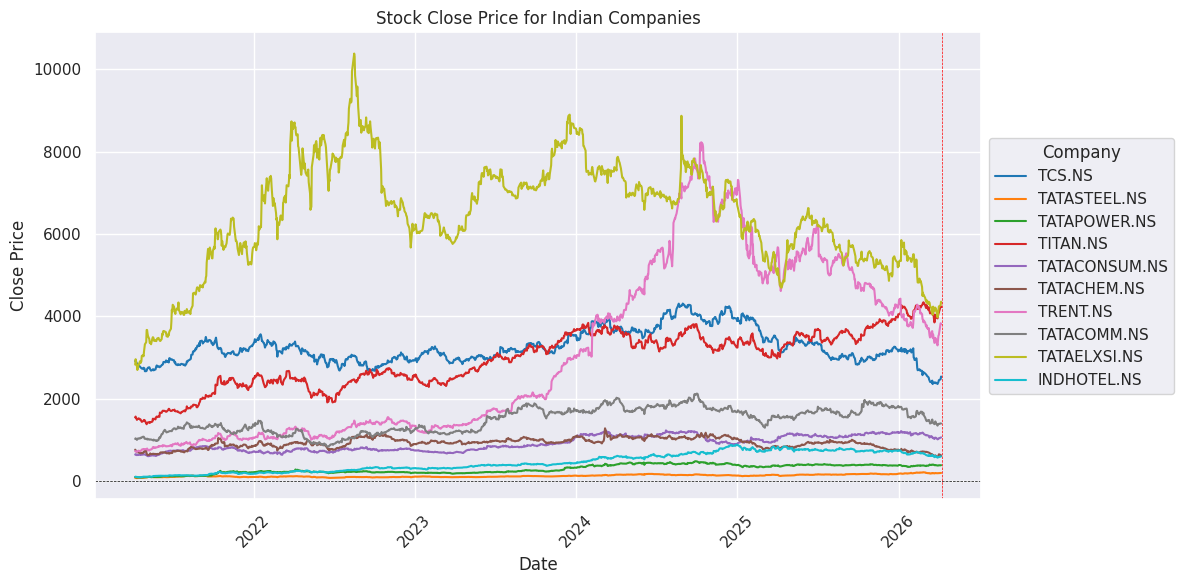

In [ ]:
# Set the style for the plot
sns.set(style="darkgrid")

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the close prices for each company
ax = sns.lineplot(
    x=data.index,
    y="Close",
    data=data,
    hue="Company",
    palette="tab10"
)

# Set titles and labels
ax.set(
    title="Stock Close Price for Indian Companies",
    xlabel="Date",
    ylabel="Close Price"
)

# Display the legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='Company')

# Rotate x-axis labels
plt.xticks(rotation=45)

# grid lines
ax.grid(True)

# Add a horizontal line at y=0 for reference
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)

# horizontal line at y=0 for reference
plt.axvline(end_date, color='red', linestyle='--', linewidth=0.5, label='Today')

# plot
plt.tight_layout()
plt.show()

### 2.2 Adjusted Close Price Each Stock

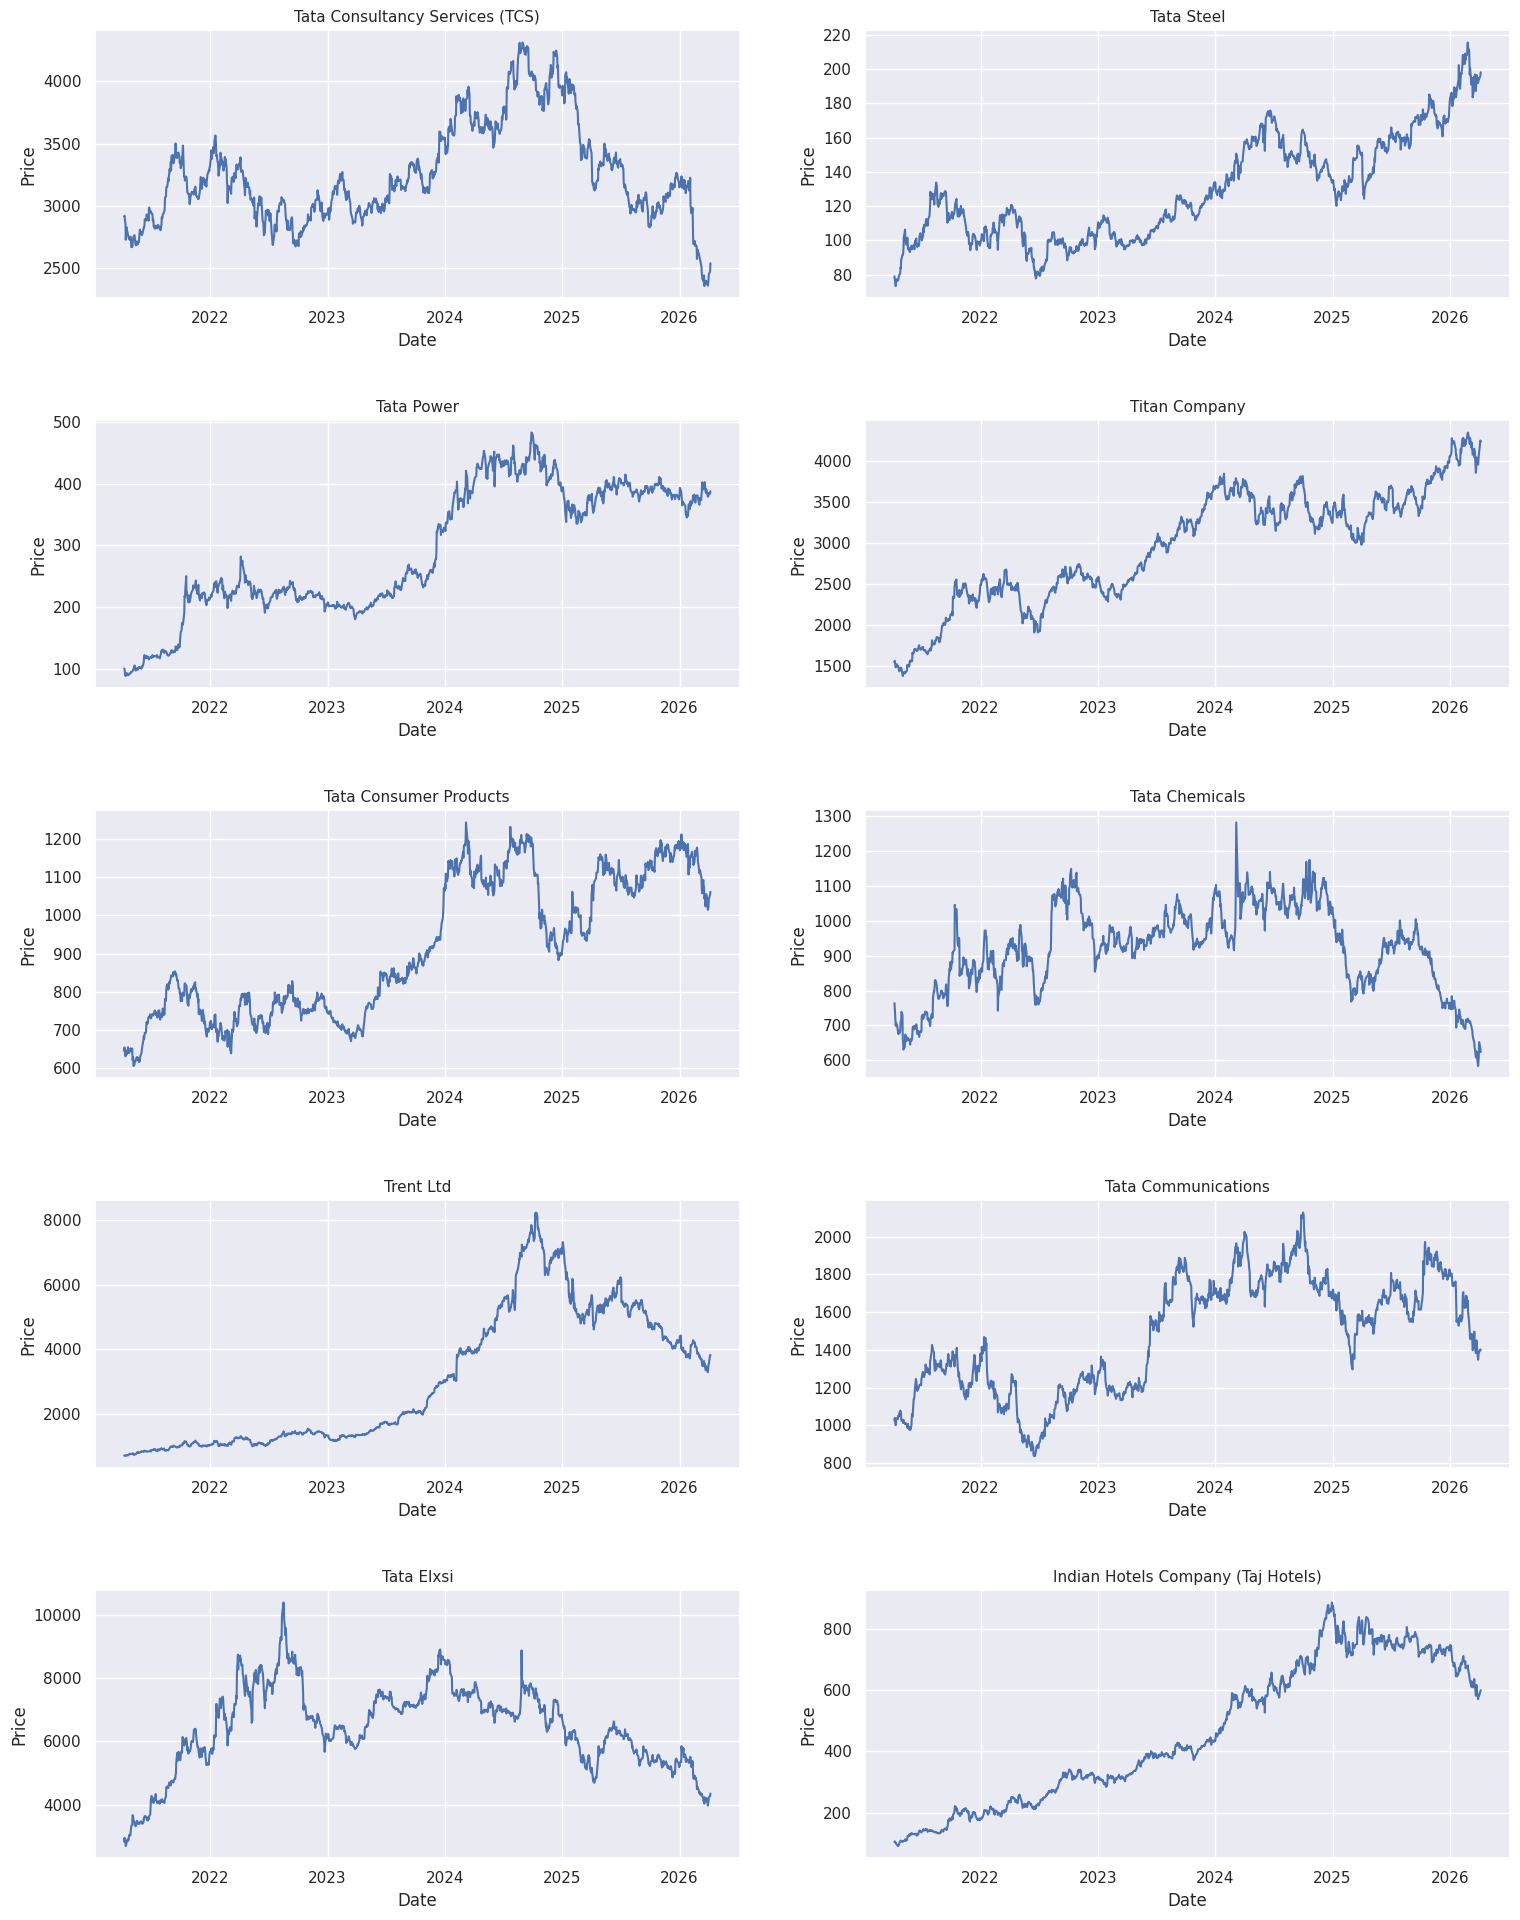

In [ ]:
num_companies = len(stock_dfs)

num_cols = 2
num_rows = int(np.ceil(num_companies / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))

for ax, stock_df, company_name in zip(axes.flatten(), stock_dfs, company_names):

    column_name = "Close"

    ax.plot(stock_df[column_name], linewidth=1.5)
    ax.set_title(f"{company_name}", fontsize=11)
    ax.set_ylabel("Price")
    ax.set_xlabel("Date")

for i in range(len(stock_dfs), len(axes.flatten())):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout(pad=3.0)
plt.show()

### 2.3 Total Volume of Stock traded Each Day

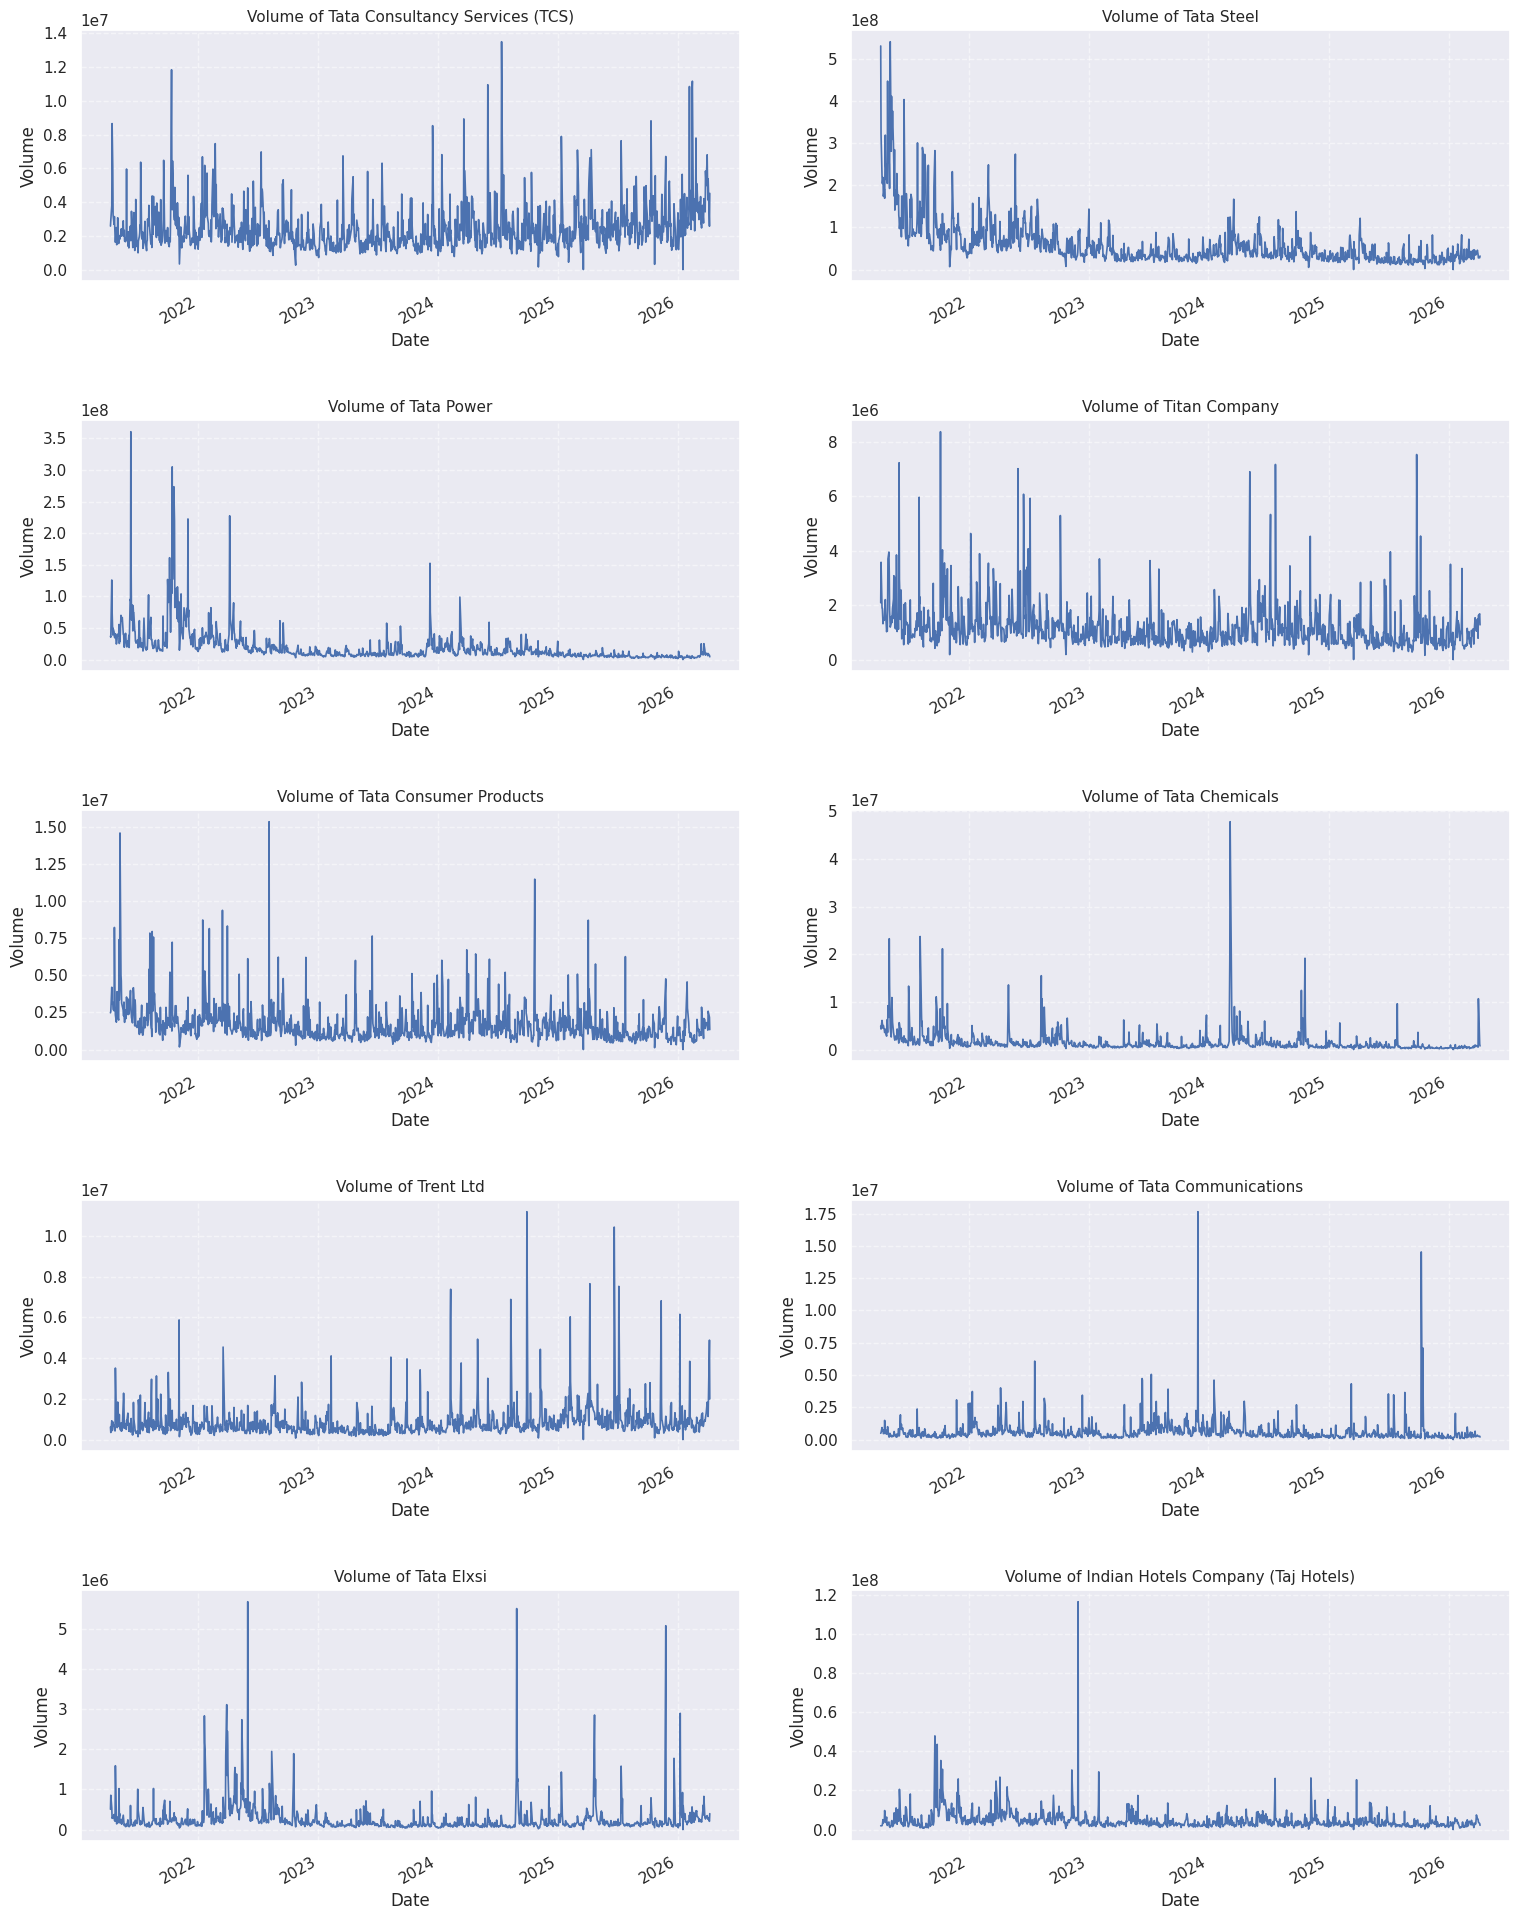

In [ ]:
num_companies = len(stock_dfs)
num_cols = 2
num_rows = int(np.ceil(num_companies / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))

for ax, stock_df, company_name in zip(axes.flatten(), stock_dfs, company_names):
    stock_df["Volume"].plot(ax=ax, linewidth=1.2)

    ax.set_ylabel("Volume")
    ax.set_xlabel("Date")
    ax.set_title(f"Volume of {company_name}", fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)

for i in range(num_companies, len(axes.flatten())):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout(pad=3.0)
plt.show()

### 2.4 Moving Average of Each Stock

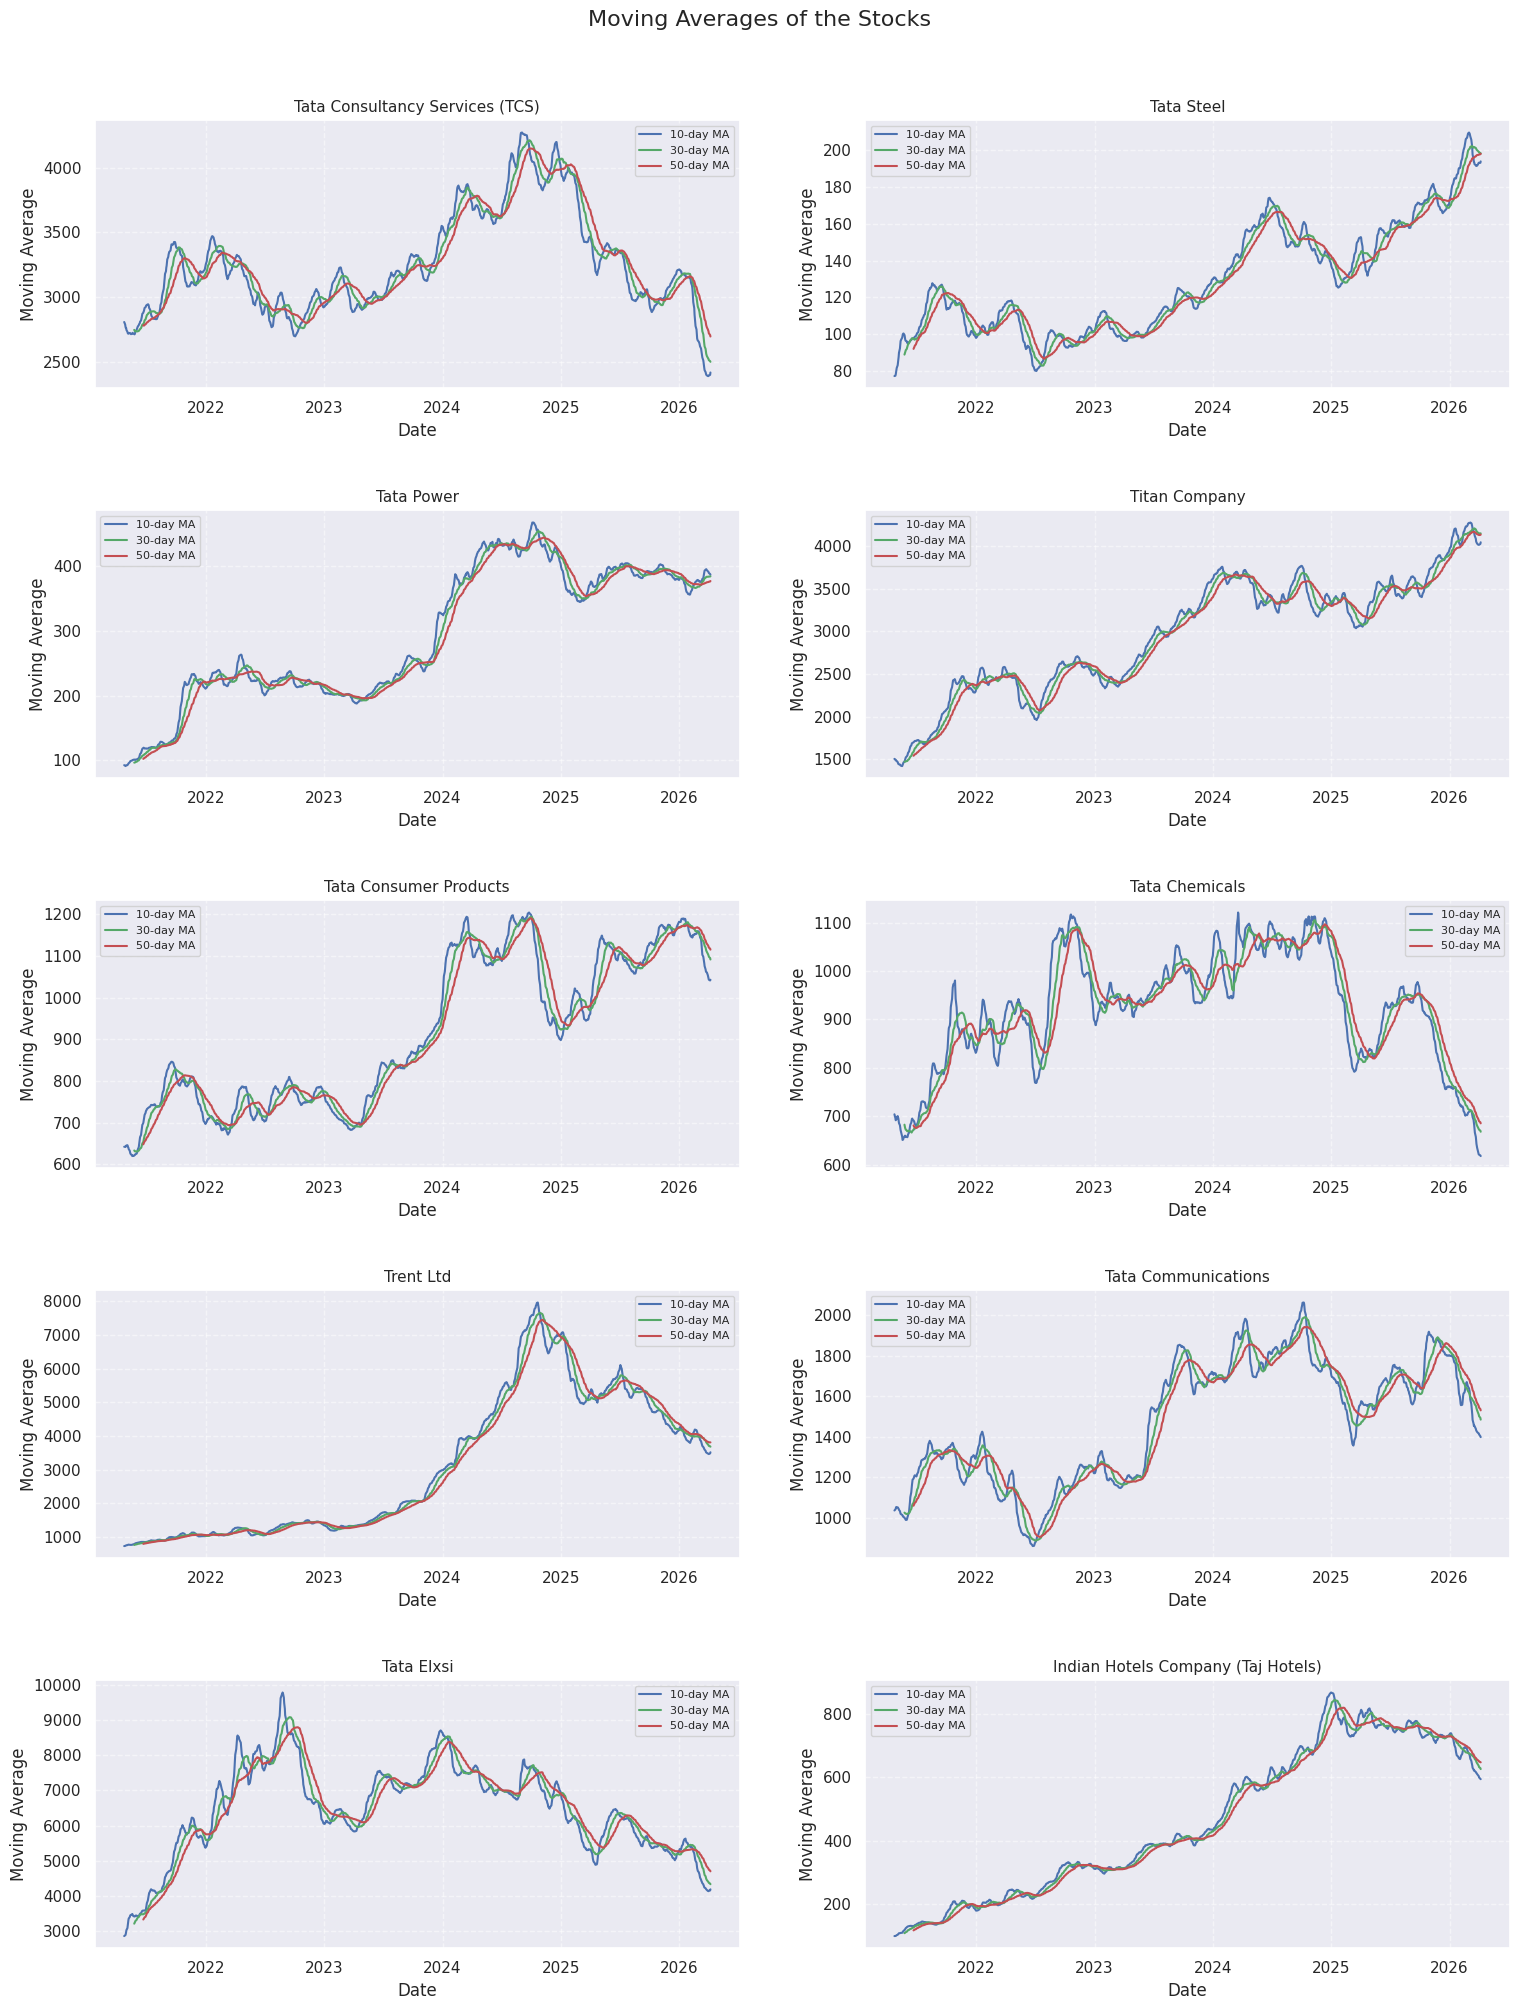

In [ ]:
moving_averages = [10, 30, 50]
line_colors = ['b', 'g', 'r']

num_companies = len(stock_dfs)
num_cols = 2
num_rows = int(np.ceil(num_companies / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))

for ax, stock_df, company_name in zip(axes.flatten(), stock_dfs, company_names):

    for ma, color in zip(moving_averages, line_colors):
        ma_col = f"MA for {ma} days"

        if "Close" in stock_df.columns:
            stock_df[ma_col] = stock_df["Close"].rolling(ma).mean()

            sns.lineplot(
                x=stock_df.index,
                y=stock_df[ma_col],
                ax=ax,
                label=f"{ma}-day MA",
                color=color,
            )
        else:
            print(f"Closing price data not found for {company_name}")

    ax.set_title(f"{company_name}", fontsize=11)
    ax.set_ylabel("Moving Average")
    ax.set_xlabel("Date")
    ax.grid(True, linestyle='--', alpha=0.5)

    ax.legend(fontsize=8)

for i in range(num_companies, len(axes.flatten())):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout(pad=3.0)

plt.suptitle("Moving Averages of the Stocks", fontsize=16, y=1.02)

plt.show()

### 2.5 Daily Return

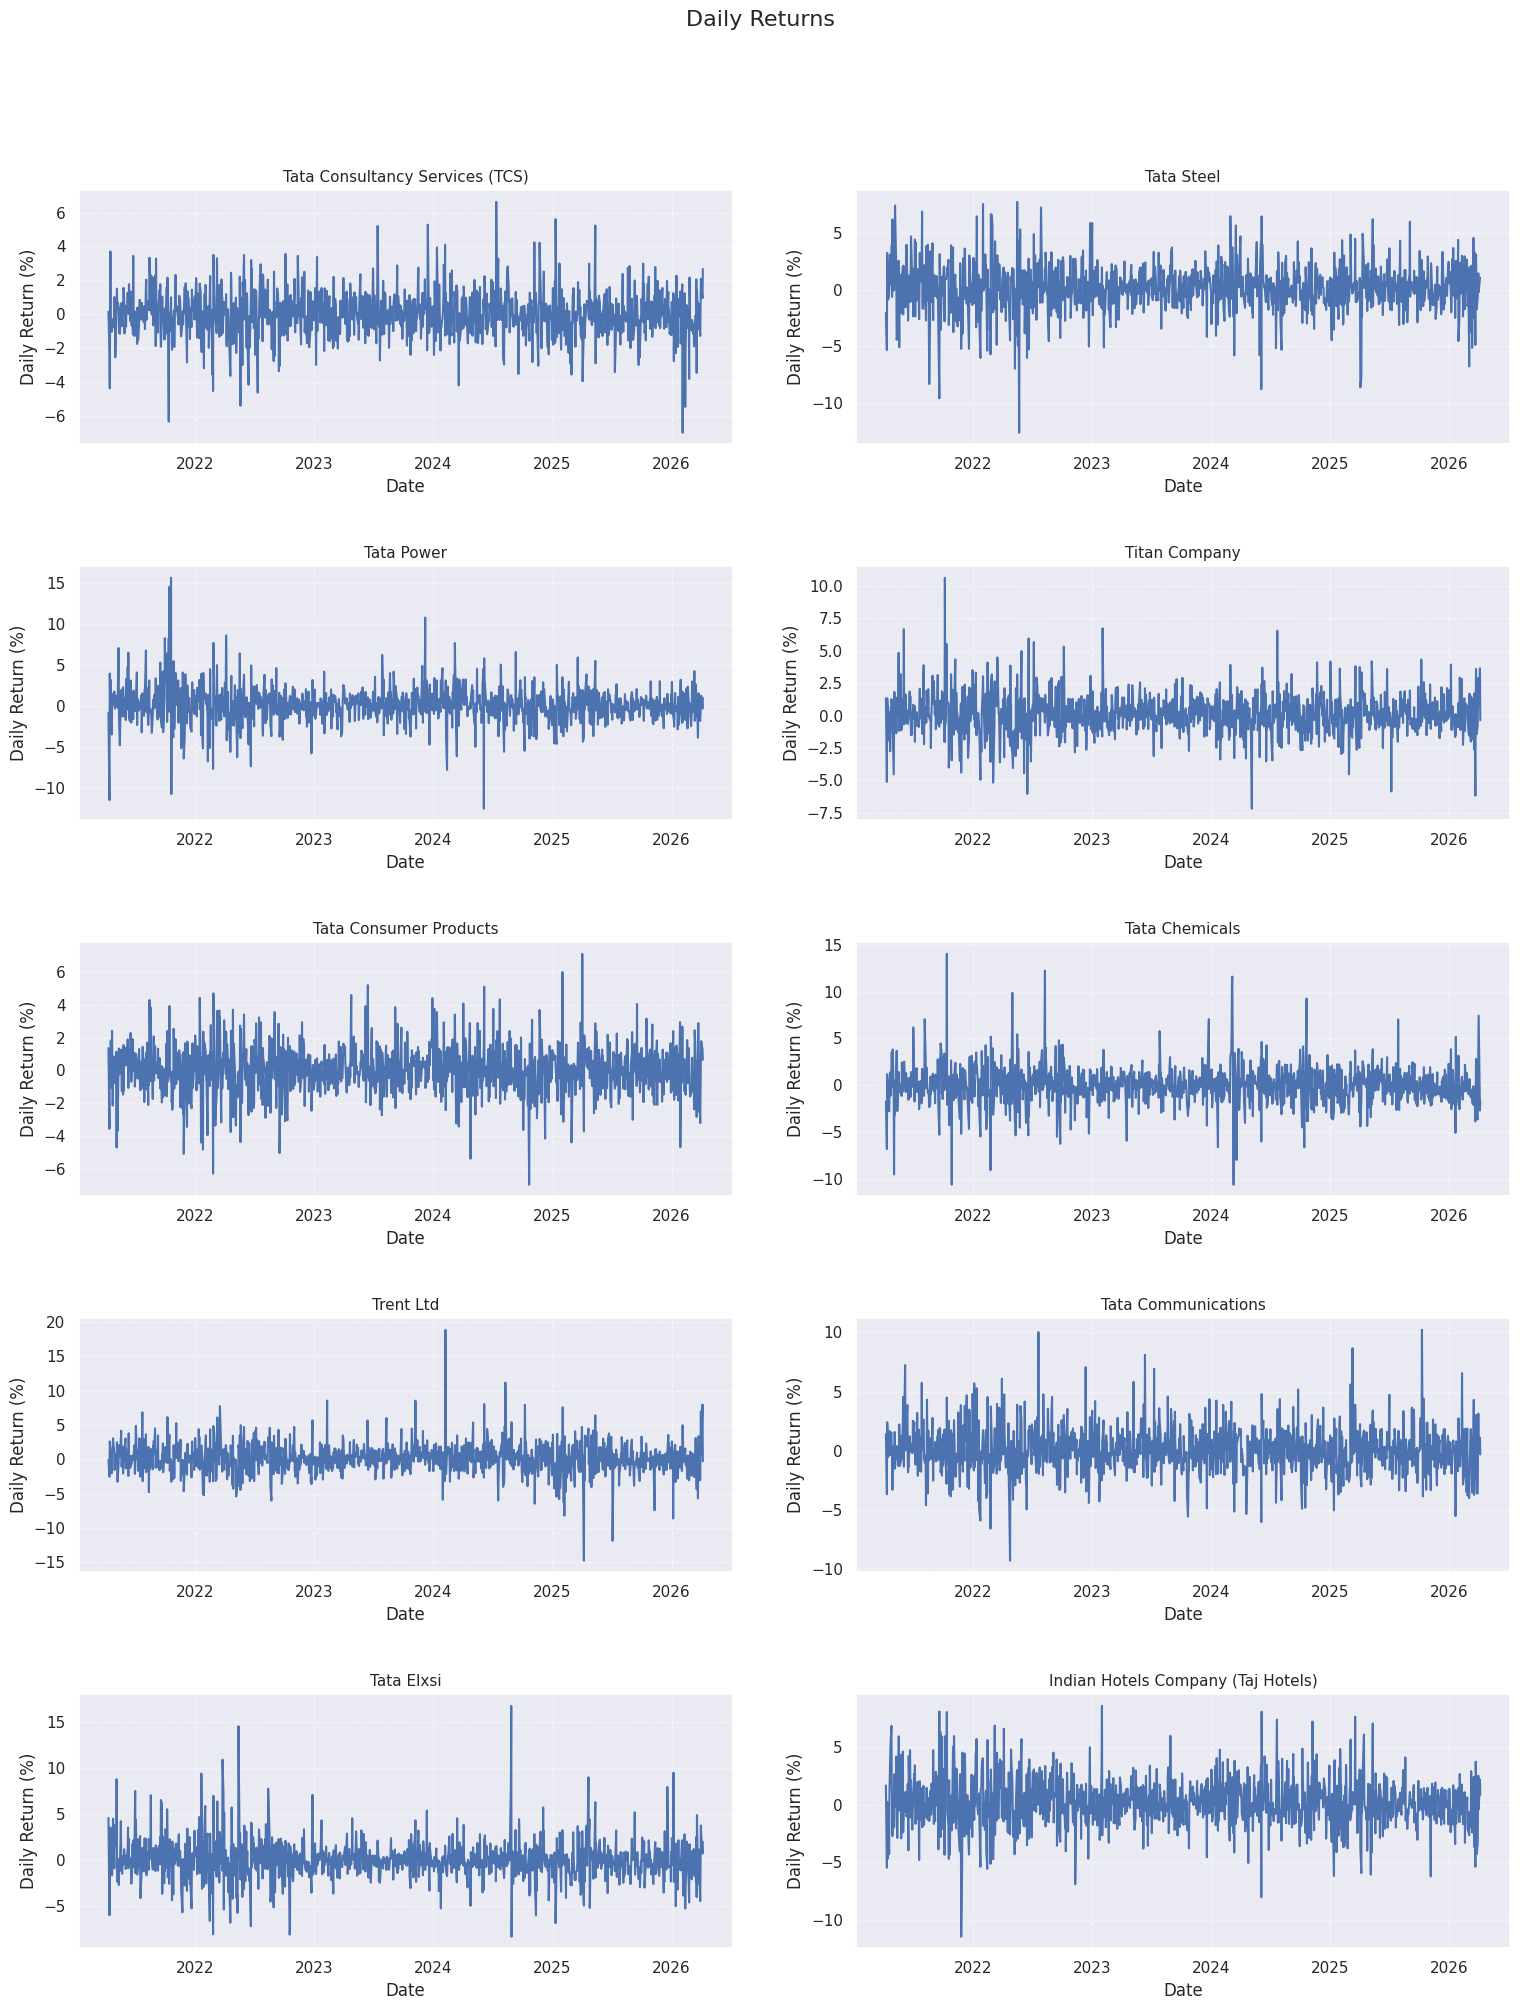

In [ ]:
num_companies = len(stock_dfs)
num_cols = 2
num_rows = int(np.ceil(num_companies / num_cols))

plt.figure(figsize=(16, 4 * num_rows))

for i, stock_df in enumerate(stock_dfs, 1):
    plt.subplot(num_rows, num_cols, i)

    if "Daily Return" not in stock_df.columns:
        if "Close" in stock_df.columns:
            stock_df["Daily Return"] = stock_df["Close"].pct_change() * 100
        else:
            print(f"Skipping {company_names[i-1]} (no Close data)")
            continue

    sns.lineplot(
        x=stock_df.index,
        y=stock_df["Daily Return"],
        color='b',
    )

    plt.title(f"{company_names[i-1]}", fontsize=11)
    plt.xlabel("Date")
    plt.ylabel("Daily Return (%)")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Daily Returns", fontsize=16, y=1.02)
plt.tight_layout(pad=3.0)

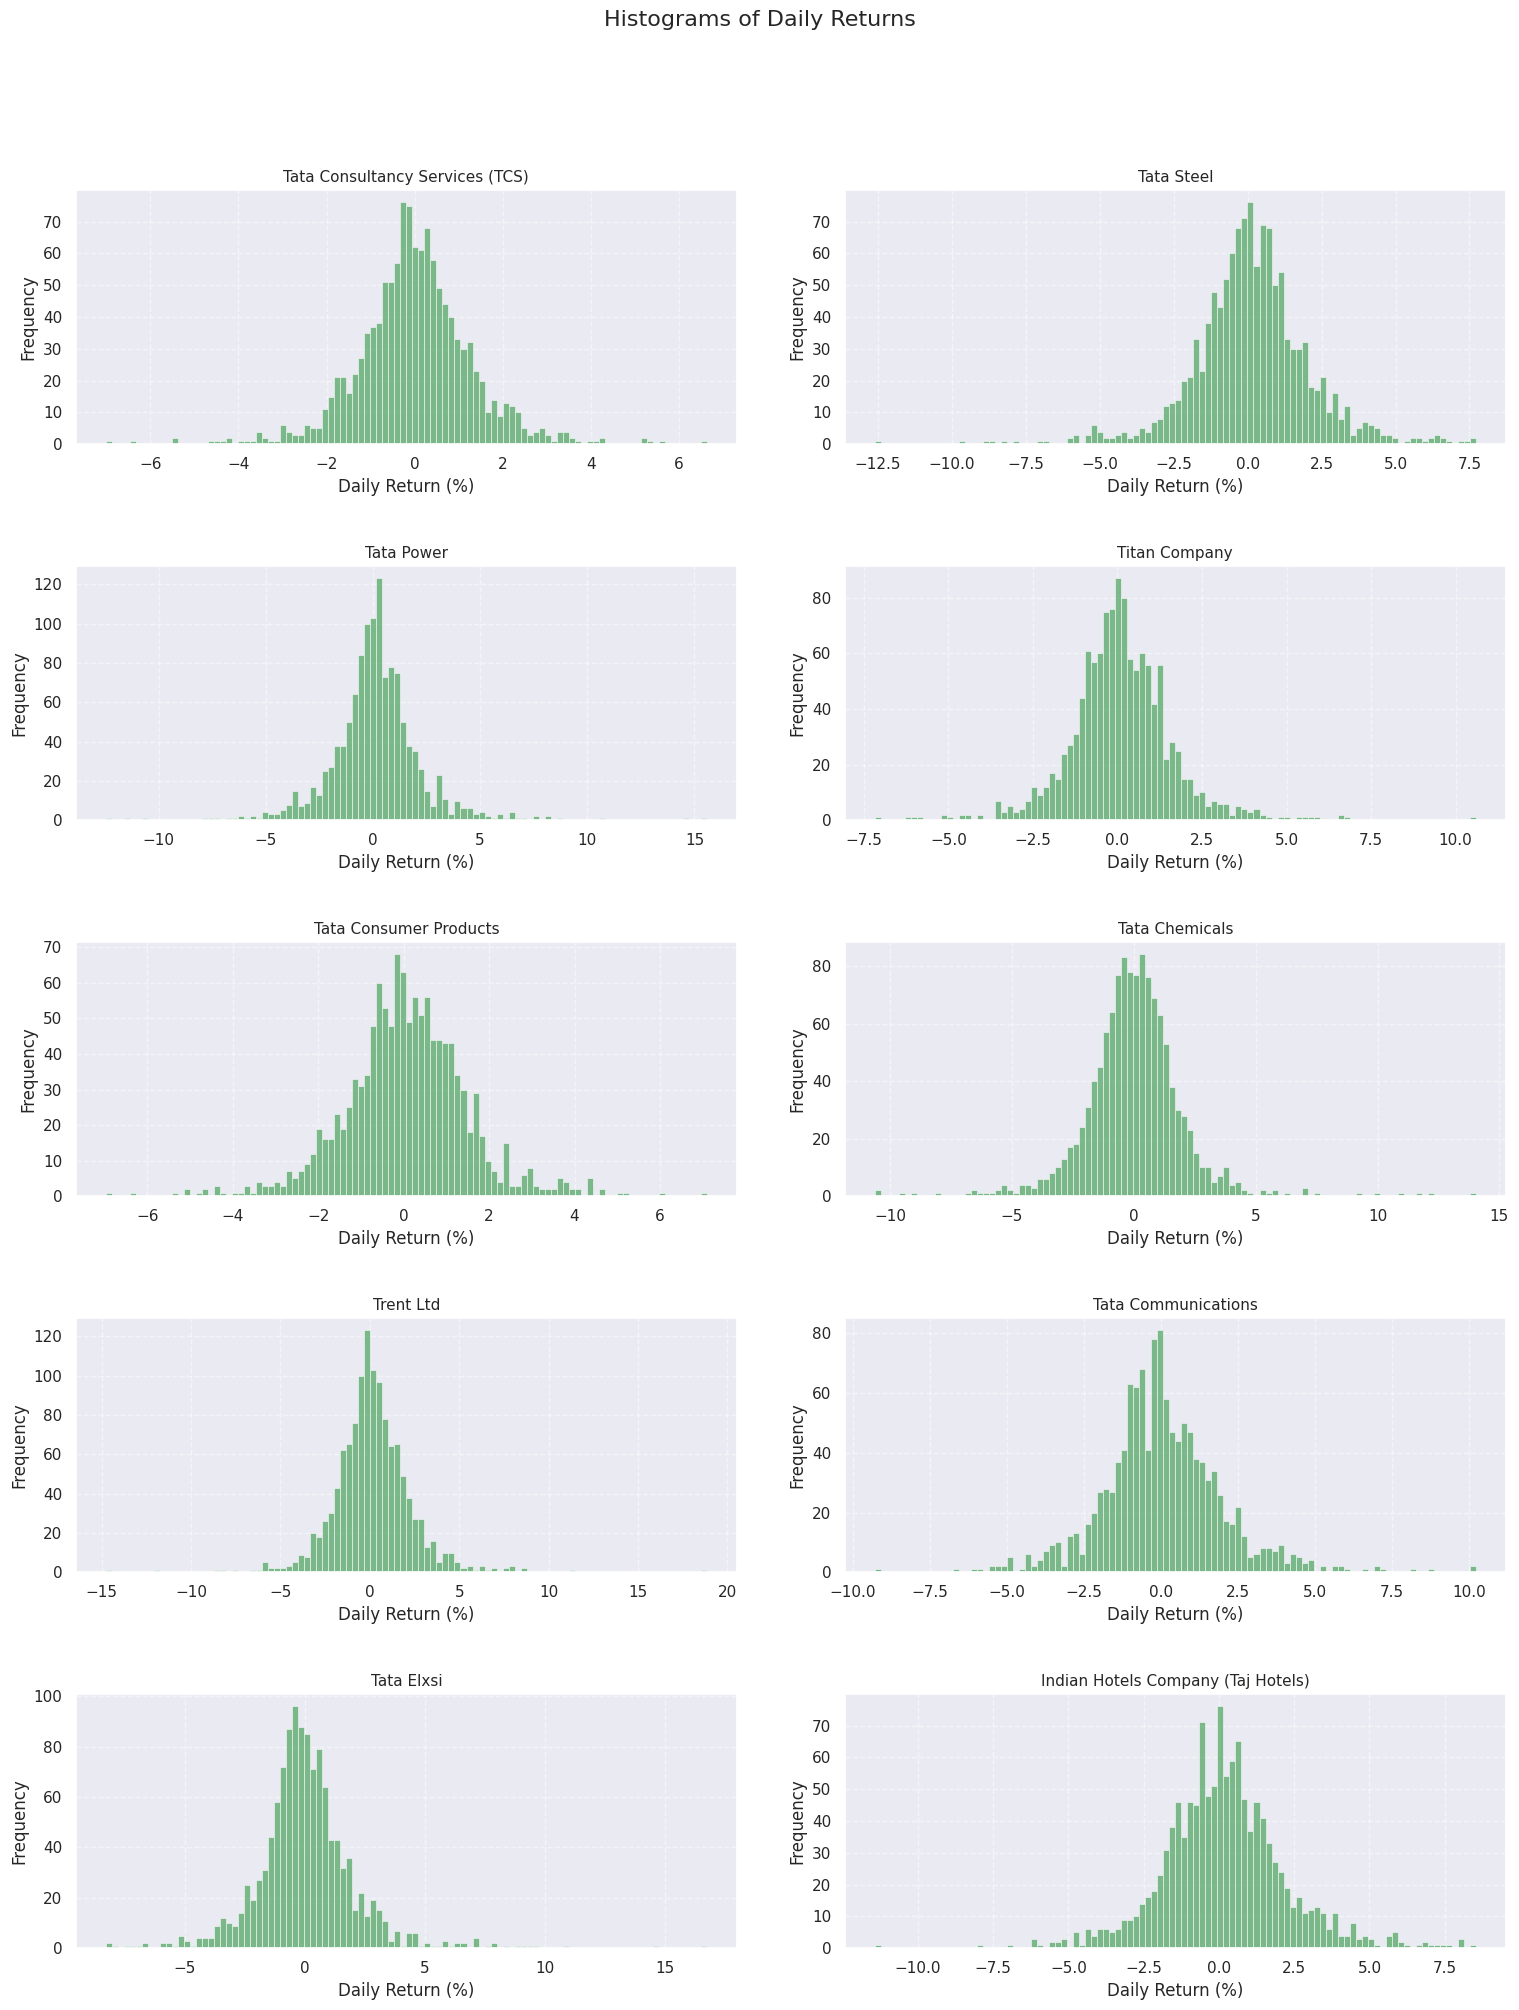

In [ ]:
plt.figure(figsize=(16, 4 * num_rows))

for i, stock_df in enumerate(stock_dfs, 1):
    plt.subplot(num_rows, num_cols, i)

    if "Daily Return" not in stock_df.columns:
        if "Close" in stock_df.columns:
            stock_df["Daily Return"] = stock_df["Close"].pct_change() * 100
        else:
            continue

    sns.histplot(
        stock_df["Daily Return"].dropna(),
        bins=100,
        color='g',
    )

    plt.title(f"{company_names[i-1]}", fontsize=11)
    plt.xlabel("Daily Return (%)")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Histograms of Daily Returns", fontsize=16, y=1.02)
plt.tight_layout(pad=3.0)

plt.show()

### 2.6 Correlation between different stocks & closing prices

In [ ]:
# Create a DataFrame containing only the closing prices of Indian stocks
closing_df = data.pivot(columns='Company', values='Close')

# Print the closing prices DataFrame
print(closing_df.head())


Company                    INDHOTEL.NS  TATACHEM.NS  TATACOMM.NS  \
Date                                                               
2021-04-08 00:00:00+05:30   104.151031   763.998108  1025.576782   
2021-04-09 00:00:00+05:30   105.873329   750.759094  1039.981445   
2021-04-12 00:00:00+05:30   100.084503   699.527405  1001.848633   
2021-04-13 00:00:00+05:30   100.323715   707.778625  1026.043091   
2021-04-15 00:00:00+05:30    95.635231   698.268799  1038.956055   

Company                    TATACONSUM.NS  TATAELXSI.NS  TATAPOWER.NS  \
Date                                                                   
2021-04-08 00:00:00+05:30     645.242493   2829.855957    100.823418   
2021-04-09 00:00:00+05:30     653.997070   2960.279541    100.006844   
2021-04-12 00:00:00+05:30     630.715576   2783.851807     88.574738   
2021-04-13 00:00:00+05:30     638.748718   2698.334473     92.081223   
2021-04-15 00:00:00+05:30     634.275208   2794.446289     90.448082   

Company           

In [ ]:
pct_closing = closing_df.pct_change()
pct_closing

Company,INDHOTEL.NS,TATACHEM.NS,TATACOMM.NS,TATACONSUM.NS,TATAELXSI.NS,TATAPOWER.NS,TATASTEEL.NS,TCS.NS,TITAN.NS,TRENT.NS
Date,,,,,,,,,,
2021-04-08 00:00:00+05:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-09 00:00:00+05:30,0.016537,-0.017329,0.014045,0.013568,0.046088,-0.008099,-0.020579,0.001477,0.013174,-0.000754
2021-04-12 00:00:00+05:30,-0.054677,-0.068240,-0.036667,-0.035599,-0.059598,-0.114313,-0.053307,-0.022786,-0.051225,-0.025302
2021-04-13 00:00:00+05:30,0.002390,0.011795,0.024150,0.012737,-0.030719,0.039588,0.032235,-0.043893,0.013340,0.026029
2021-04-15 00:00:00+05:30,-0.046734,-0.013436,0.012585,-0.007004,0.035619,-0.017736,0.021843,0.037016,0.005194,0.014878
...,...,...,...,...,...,...,...,...,...,...
2026-03-30 00:00:00+05:30,-0.033762,-0.036508,-0.036044,-0.032141,-0.044270,-0.018019,-0.007039,-0.012930,-0.007560,-0.030533
2026-04-01 00:00:00+05:30,0.024958,0.040291,0.031382,0.008869,0.037846,0.003828,0.014281,0.020900,0.028876,0.069998
2026-04-02 00:00:00+05:30,-0.004187,0.074413,-0.002086,0.017777,0.027671,0.012625,-0.002364,0.017648,0.007797,0.006834


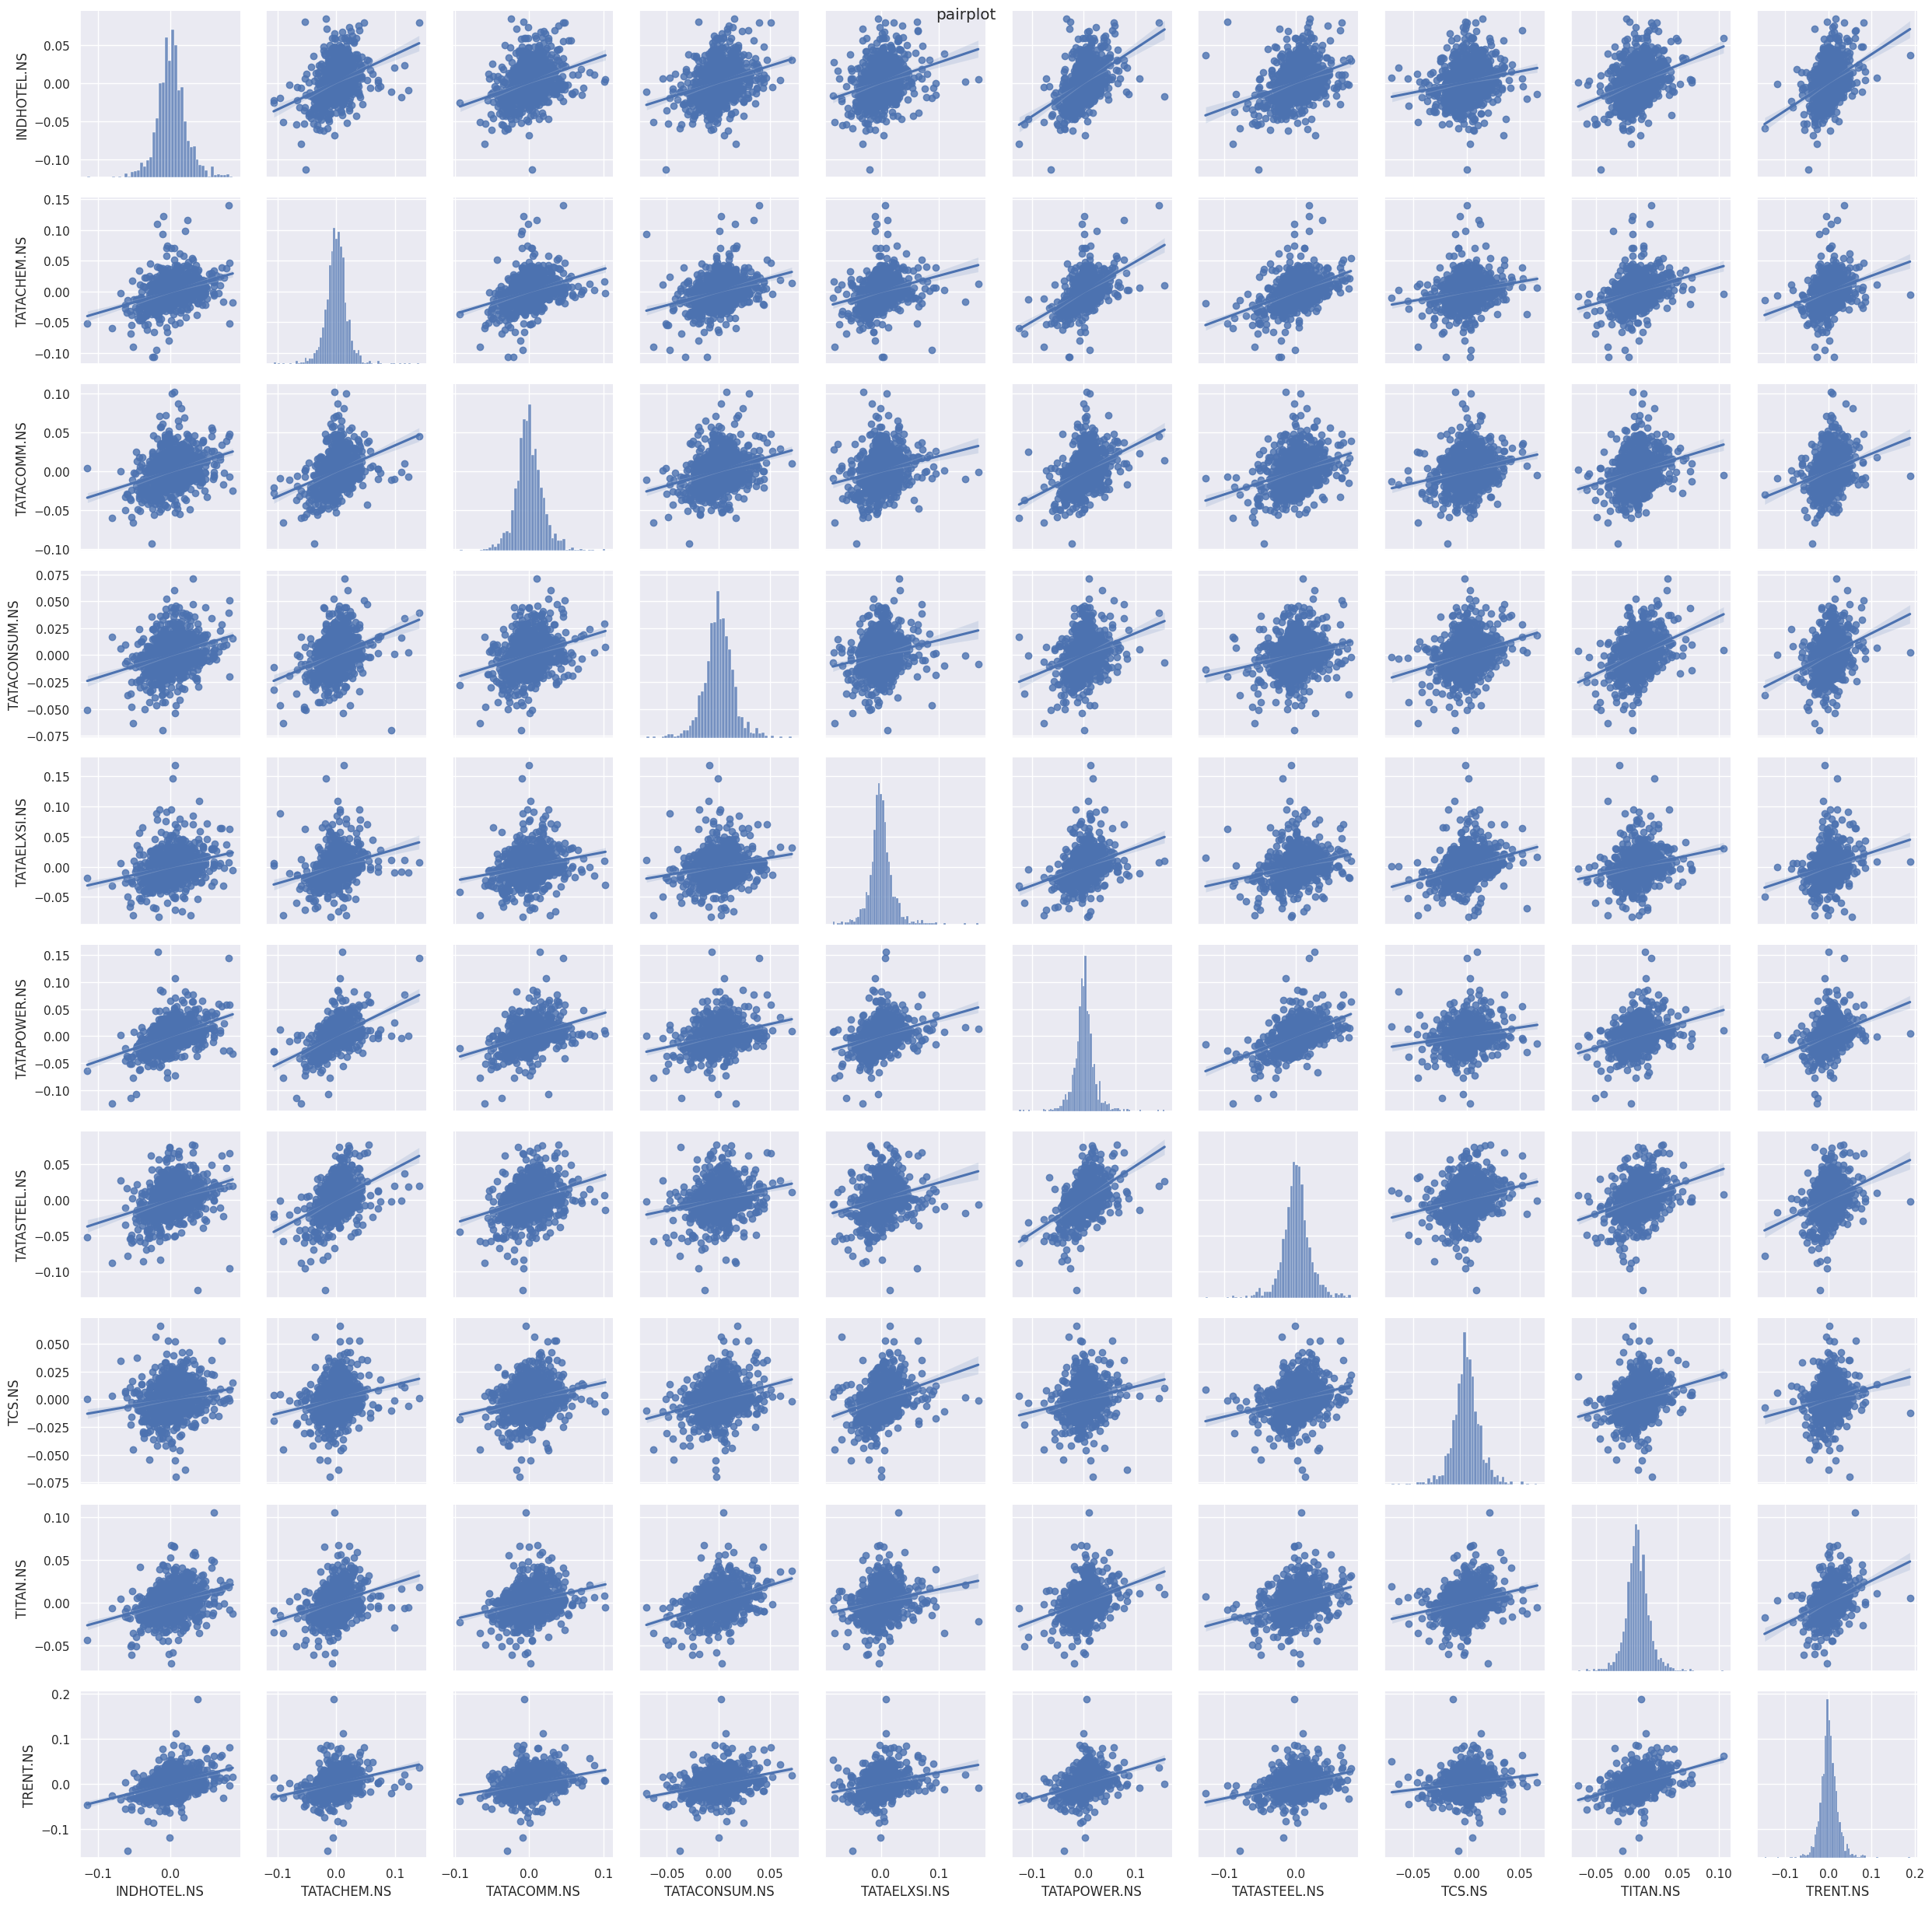

In [ ]:
sns.pairplot(pct_closing, kind = "reg")
plt.suptitle("pairplot")
plt.tight_layout()

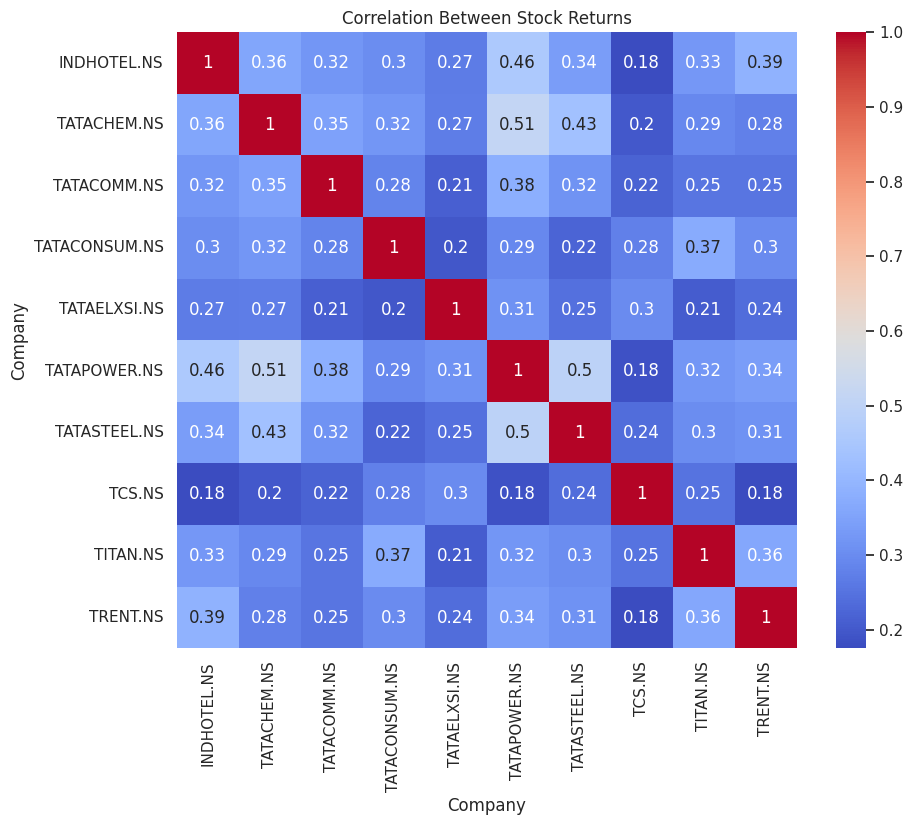

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(pct_closing.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Between Stock Returns")
plt.show()

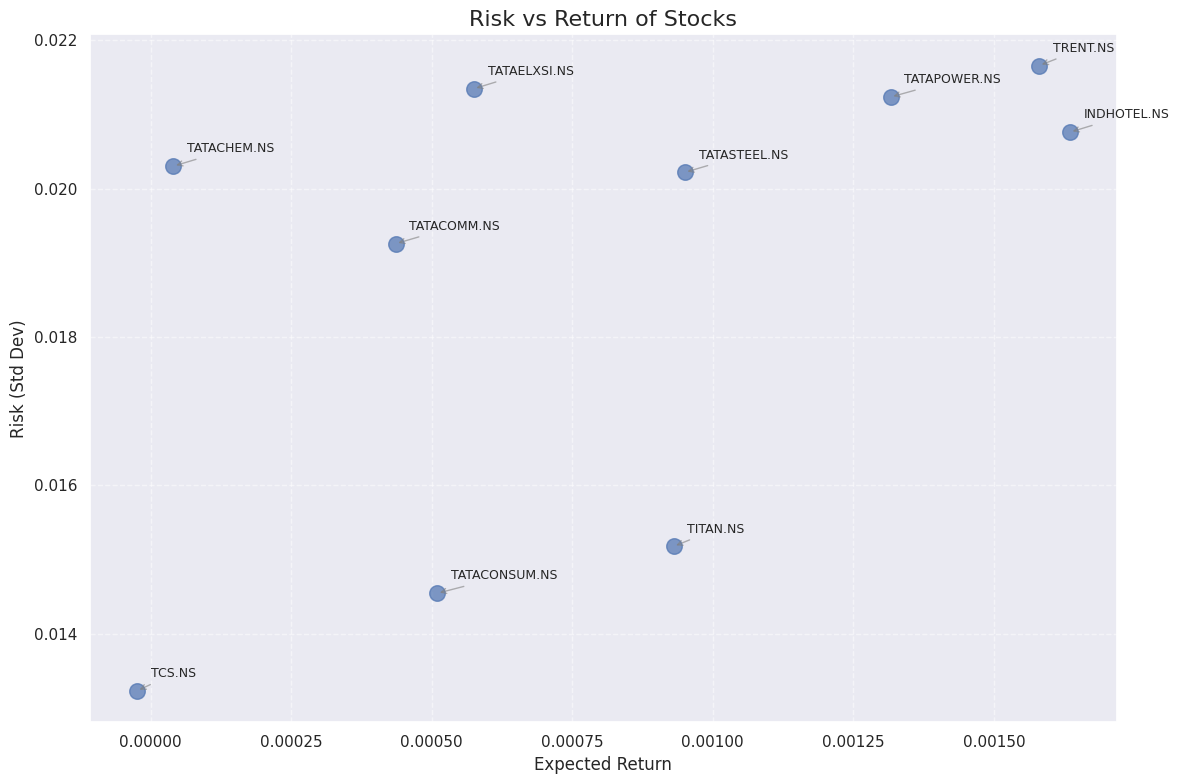

In [ ]:
pct_closing = pct_closing.dropna()
area = np.pi * 40

plt.figure(figsize=(12, 8))

plt.scatter(
    pct_closing.mean(),
    pct_closing.std(),
    s=area,
    alpha=0.7
)

plt.xlabel("Expected Return", fontsize=12)
plt.ylabel("Risk (Std Dev)", fontsize=12)
plt.title("Risk vs Return of Stocks", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

for label, x, y in zip(
    pct_closing.columns,
    pct_closing.mean(),
    pct_closing.std()
):
    plt.annotate(
        label,
        xy=(x, y),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9,
        arrowprops=dict(
            arrowstyle='->',
            color='gray',
            alpha=0.6
        )
    )

plt.tight_layout()
plt.show()

# **Phase 2: Data Pre-Processing**

# **3. Feature Engineering**

# 3.1 Add new statistical features related to stock price for better generalization

In [ ]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=8101c6614b90037ccff588812e684f4bc7a768b746f1f3a3ea1c7a99490359cb
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
import ta

def add_features(df):
    """
    Adds technical indicators to a single stock DataFrame.
    Input:  df with columns [Open, High, Low, Close, Volume]
    Output: df with added feature columns
    """
    df = df.copy()

    # 1. RSI (Relative Strength Index)
    # Measures momentum: >70 = overbought, <30 = oversold
    df['RSI'] = ta.momentum.RSIIndicator(close=df['Close'], window=14).rsi()

    # 2. MACD (Moving Average Convergence Divergence)
    # Shows trend direction and strength
    macd = ta.trend.MACD(close=df['Close'], window_slow=26, window_fast=12, window_sign=9)
    df['MACD']        = macd.macd()          # MACD line
    df['MACD_Signal'] = macd.macd_signal()   # Signal line
    df['MACD_Hist']   = macd.macd_diff()     # Histogram (MACD - Signal)

    # 3. Bollinger Bands
    # Shows volatility: price touching upper/lower band = signal
    bb = ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2)
    df['BB_Upper']  = bb.bollinger_hband()   # Upper band
    df['BB_Middle'] = bb.bollinger_mavg()    # Middle (20-day MA)
    df['BB_Lower']  = bb.bollinger_lband()   # Lower band
    df['BB_Width']  = bb.bollinger_wband()   # Band width (volatility measure)

    # 4. EMA (Exponential Moving Average)
    # Gives more weight to recent prices than simple MA
    df['EMA_12'] = ta.trend.EMAIndicator(close=df['Close'], window=12).ema_indicator()
    df['EMA_26'] = ta.trend.EMAIndicator(close=df['Close'], window=26).ema_indicator()
    df['EMA_50'] = ta.trend.EMAIndicator(close=df['Close'], window=50).ema_indicator()

    # 5. Lag Features
    # Previous day's prices — gives the model "memory"
    df['Close_Lag1'] = df['Close'].shift(1)   # Yesterday's close
    df['Close_Lag5'] = df['Close'].shift(5)   # 5 days ago
    df['Return_1d']  = df['Close'].pct_change(1)  # 1-day return
    df['Return_5d']  = df['Close'].pct_change(5)  # 5-day return

    return df


# Apply feature engineering to all 10 stocks
stock_dfs_featured = []
for i, (df, name) in enumerate(zip(stock_dfs, company_names)):
    df_feat = add_features(df)
    df_feat['Company'] = stock_symbols[i]
    stock_dfs_featured.append(df_feat)
    print(f"✓ Features added for: {name}")

print("\nDone! New columns added:")
print([c for c in stock_dfs_featured[0].columns if c not in ['Open','High','Low','Close','Volume','Dividends','Stock Splits','Company']])

✓ Features added for: Tata Consultancy Services (TCS)
✓ Features added for: Tata Steel
✓ Features added for: Tata Power
✓ Features added for: Titan Company
✓ Features added for: Tata Consumer Products
✓ Features added for: Tata Chemicals
✓ Features added for: Trent Ltd
✓ Features added for: Tata Communications
✓ Features added for: Tata Elxsi
✓ Features added for: Indian Hotels Company (Taj Hotels)

Done! New columns added:
['MA for 10 days', 'MA for 30 days', 'MA for 50 days', 'Daily Return', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_Width', 'EMA_12', 'EMA_26', 'EMA_50', 'Close_Lag1', 'Close_Lag5', 'Return_1d', 'Return_5d']


# 3.2 Visualize the features for one stock (Tata Steel)

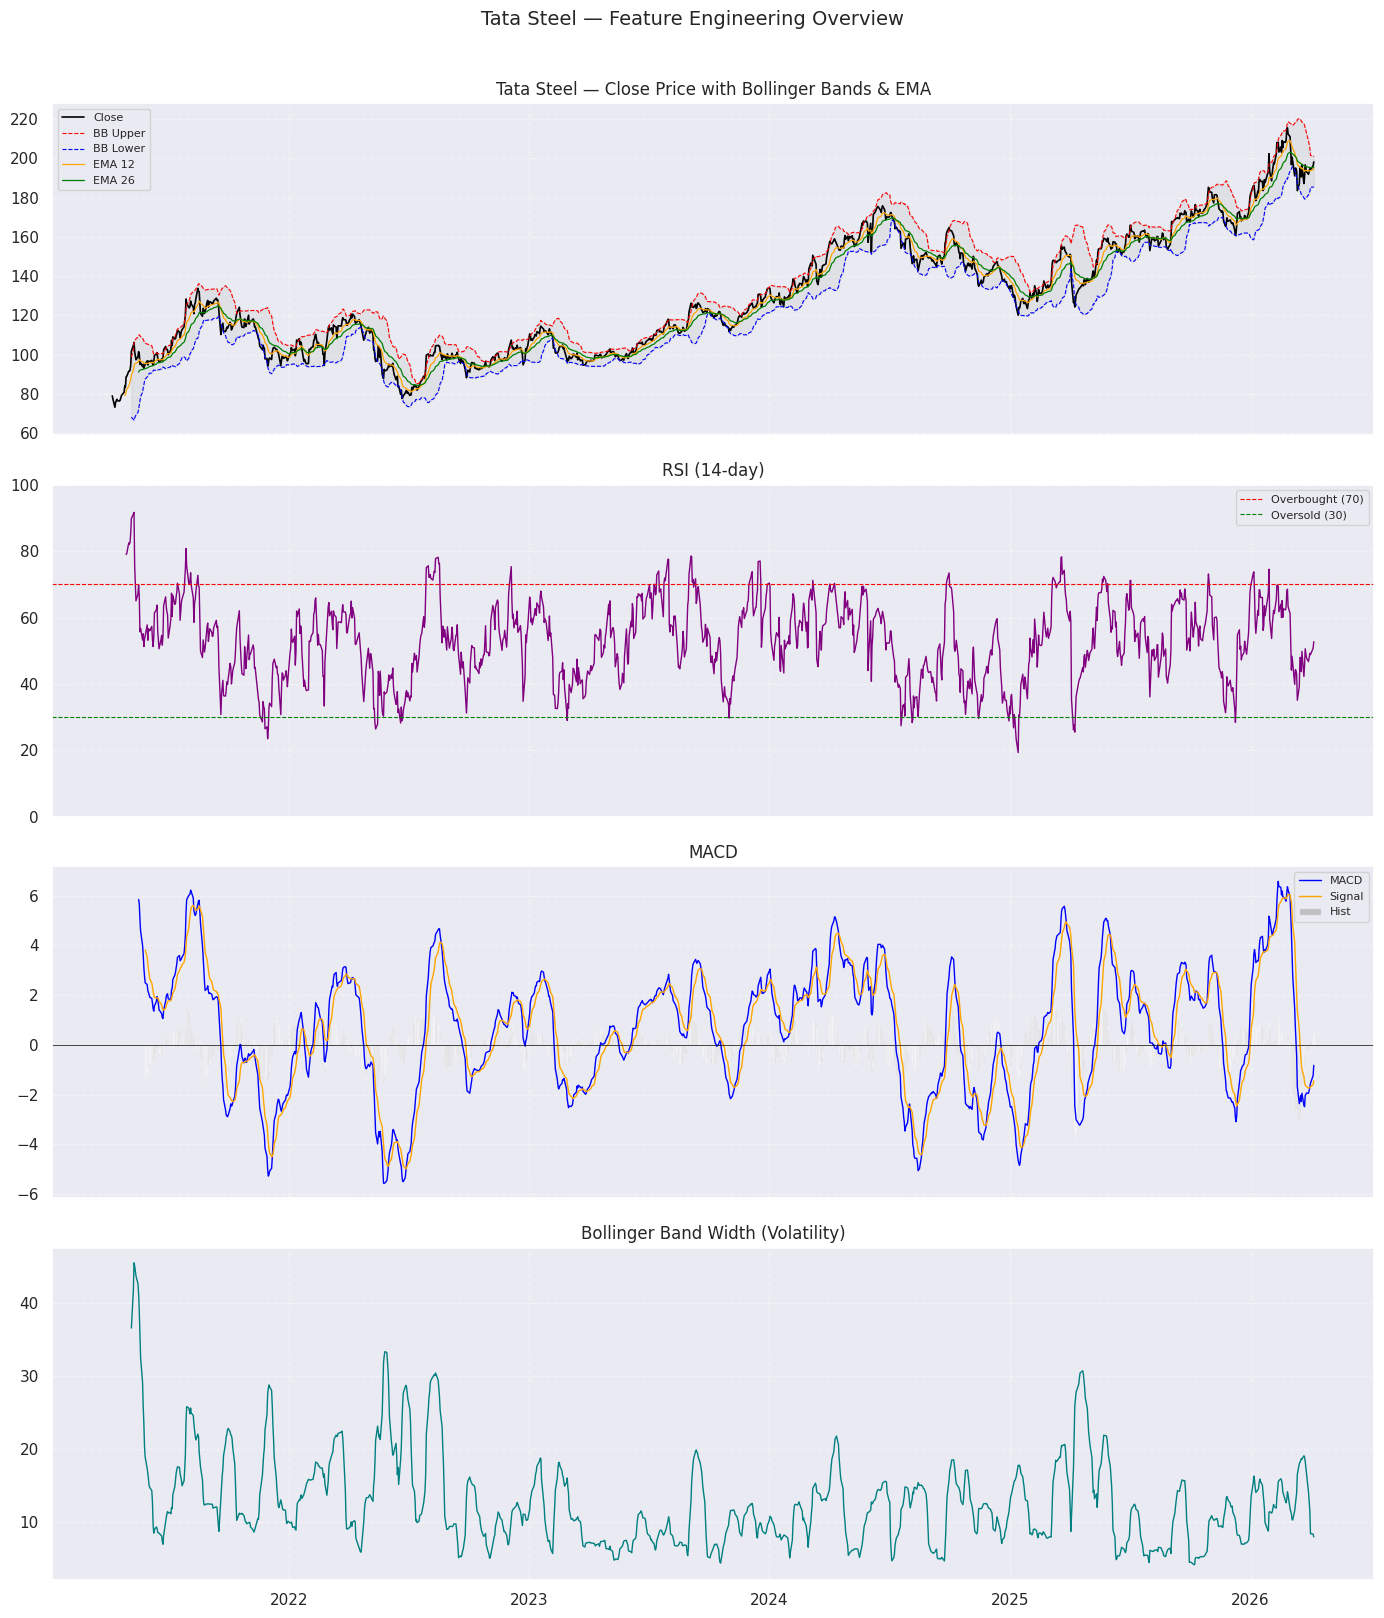

In [ ]:
# Visualize features for Tata Steel (update index accordingly)
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

tata_steel = stock_dfs_featured[1]   # <-- change index here

# Plot 1: Close price + Bollinger Bands + EMAs
ax1 = axes[0]
ax1.plot(tata_steel.index, tata_steel['Close'],     label='Close',    color='black', linewidth=1.2)
ax1.plot(tata_steel.index, tata_steel['BB_Upper'],  label='BB Upper', color='red',   linewidth=0.8, linestyle='--')
ax1.plot(tata_steel.index, tata_steel['BB_Lower'],  label='BB Lower', color='blue',  linewidth=0.8, linestyle='--')
ax1.fill_between(tata_steel.index, tata_steel['BB_Upper'], tata_steel['BB_Lower'], alpha=0.1, color='gray')
ax1.plot(tata_steel.index, tata_steel['EMA_12'],    label='EMA 12',   color='orange', linewidth=0.9)
ax1.plot(tata_steel.index, tata_steel['EMA_26'],    label='EMA 26',   color='green',  linewidth=0.9)
ax1.set_title("Tata Steel — Close Price with Bollinger Bands & EMA")
ax1.legend(fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.4)

# Plot 2: RSI
ax2 = axes[1]
ax2.plot(tata_steel.index, tata_steel['RSI'], color='purple', linewidth=1)
ax2.axhline(70, color='red',   linestyle='--', linewidth=0.8, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
ax2.set_ylim(0, 100)
ax2.set_title("RSI (14-day)")
ax2.legend(fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.4)

# Plot 3: MACD
ax3 = axes[2]
ax3.plot(tata_steel.index, tata_steel['MACD'],        label='MACD',   color='blue',  linewidth=1)
ax3.plot(tata_steel.index, tata_steel['MACD_Signal'], label='Signal', color='orange',linewidth=1)
ax3.bar(tata_steel.index,  tata_steel['MACD_Hist'],   label='Hist',   color='gray',  alpha=0.4)
ax3.axhline(0, color='black', linewidth=0.5)
ax3.set_title("MACD")
ax3.legend(fontsize=8)
ax3.grid(True, linestyle='--', alpha=0.4)

# Plot 4: Bollinger Band Width (Volatility)
ax4 = axes[3]
ax4.plot(tata_steel.index, tata_steel['BB_Width'], color='teal', linewidth=1)
ax4.set_title("Bollinger Band Width (Volatility)")
ax4.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Tata Steel — Feature Engineering Overview", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 3.3 Check for missing values for updated dataframe for one stock (Tata Steel)

In [ ]:
# Quick sanity check — print shape and first few rows
print(f"Shape: {stock_dfs_featured[1].shape}")
print(f"\nMissing values:\n{stock_dfs_featured[0].isnull().sum()}")
print(f"\nTotal Missing Values:", stock_dfs_featured[0].isnull().sum().sum())
print(f"\nSample:")
stock_dfs_featured[0][['Close','RSI','MACD','BB_Upper','BB_Lower','EMA_12','Close_Lag1']].tail(5)

Shape: (1235, 27)

Missing values:
Open               0
High               0
Low                0
Close              0
Volume             0
Dividends          0
Stock Splits       0
Company            0
MA for 10 days     9
MA for 30 days    29
MA for 50 days    49
Daily Return       1
RSI               13
MACD              25
MACD_Signal       33
MACD_Hist         33
BB_Upper          19
BB_Middle         19
BB_Lower          19
BB_Width          19
EMA_12            11
EMA_26            25
EMA_50            49
Close_Lag1         1
Close_Lag5         5
Return_1d          1
Return_5d          5
dtype: int64

Total Missing Values: 365

Sample:


,Close,RSI,MACD,BB_Upper,BB_Lower,EMA_12,Close_Lag1
Date,,,,,,,
2026-03-30 00:00:00+05:30,2358.899902,28.434774,-104.820476,2640.335919,2282.704072,2413.866046,2389.800049
2026-04-01 00:00:00+05:30,2408.199951,36.498711,-97.507993,2610.782321,2289.337674,2412.994339,2358.899902
2026-04-02 00:00:00+05:30,2450.699951,42.512457,-87.277324,2584.131745,2299.708245,2418.795202,2408.199951
2026-04-06 00:00:00+05:30,2473.899902,45.544181,-76.416520,2562.885140,2309.564835,2427.272849,2450.699951
2026-04-07 00:00:00+05:30,2539.800049,53.108863,-61.779508,2553.050462,2315.499513,2444.584726,2473.899902


# **4. Stationarity Check & Time Series Analysis**

# 4.1 Check for stationarity for each stock

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def adf_test(series, name=""):
    """
    Runs the Augmented Dickey-Fuller test.
    H0 (null hypothesis): Series is NON-stationary
    If p-value < 0.05 → reject H0 → series IS stationary
    """
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n{'─'*45}")
    print(f"Stock: {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical (1%) : {result[4]['1%']:.4f}")
    print(f"  Critical (5%) : {result[4]['5%']:.4f}")
    if result[1] < 0.05:
        print(f"  Result ✓ : STATIONARY (p < 0.05)")
    else:
        print(f"  Result ✗ : NON-STATIONARY → apply differencing")
    return result[1]  # return p-value


# Run ADF test on Close price for all 10 stocks
print("ADF TEST RESULTS — RAW CLOSE PRICE")
print("=" * 45)

adf_results = {}
for df, name, symbol in zip(stock_dfs_featured, company_names, stock_symbols):
    p_val = adf_test(df['Close'].dropna(), name=name)
    adf_results[symbol] = p_val

ADF TEST RESULTS — RAW CLOSE PRICE

─────────────────────────────────────────────
Stock: Tata Consultancy Services (TCS)
  ADF Statistic : -1.5757
  p-value       : 0.4958
  Critical (1%) : -3.4357
  Critical (5%) : -2.8639
  Result ✗ : NON-STATIONARY → apply differencing

─────────────────────────────────────────────
Stock: Tata Steel
  ADF Statistic : -1.0999
  p-value       : 0.7151
  Critical (1%) : -3.4357
  Critical (5%) : -2.8639
  Result ✗ : NON-STATIONARY → apply differencing

─────────────────────────────────────────────
Stock: Tata Power
  ADF Statistic : -1.7423
  p-value       : 0.4094
  Critical (1%) : -3.4357
  Critical (5%) : -2.8639
  Result ✗ : NON-STATIONARY → apply differencing

─────────────────────────────────────────────
Stock: Titan Company
  ADF Statistic : -1.3995
  p-value       : 0.5825
  Critical (1%) : -3.4357
  Critical (5%) : -2.8639
  Result ✗ : NON-STATIONARY → apply differencing

─────────────────────────────────────────────
Stock: Tata Consumer Produ

# 4.2 Apply differencing to make series stationary

In [ ]:
print("\n\nADF TEST RESULTS — AFTER 1ST DIFFERENCING")
print("=" * 45)

for df, name, symbol in zip(stock_dfs_featured, company_names, stock_symbols):
    # 1st difference = today's price minus yesterday's price
    diff_series = df['Close'].diff().dropna()
    p_val = adf_test(diff_series, name=f"{name} (1st diff)")
    adf_results[f"{symbol}_diff"] = p_val

# After differencing, all stocks should show p < 0.05



ADF TEST RESULTS — AFTER 1ST DIFFERENCING

─────────────────────────────────────────────
Stock: Tata Consultancy Services (TCS) (1st diff)
  ADF Statistic : -34.2742
  p-value       : 0.0000
  Critical (1%) : -3.4357
  Critical (5%) : -2.8639
  Result ✓ : STATIONARY (p < 0.05)

─────────────────────────────────────────────
Stock: Tata Steel (1st diff)
  ADF Statistic : -35.3892
  p-value       : 0.0000
  Critical (1%) : -3.4357
  Critical (5%) : -2.8639
  Result ✓ : STATIONARY (p < 0.05)

─────────────────────────────────────────────
Stock: Tata Power (1st diff)
  ADF Statistic : -15.8759
  p-value       : 0.0000
  Critical (1%) : -3.4357
  Critical (5%) : -2.8639
  Result ✓ : STATIONARY (p < 0.05)

─────────────────────────────────────────────
Stock: Titan Company (1st diff)
  ADF Statistic : -14.0268
  p-value       : 0.0000
  Critical (1%) : -3.4357
  Critical (5%) : -2.8639
  Result ✓ : STATIONARY (p < 0.05)

─────────────────────────────────────────────
Stock: Tata Consumer Prod

# 4.3 ACF and PACF plots for one stock (Tata Steel)

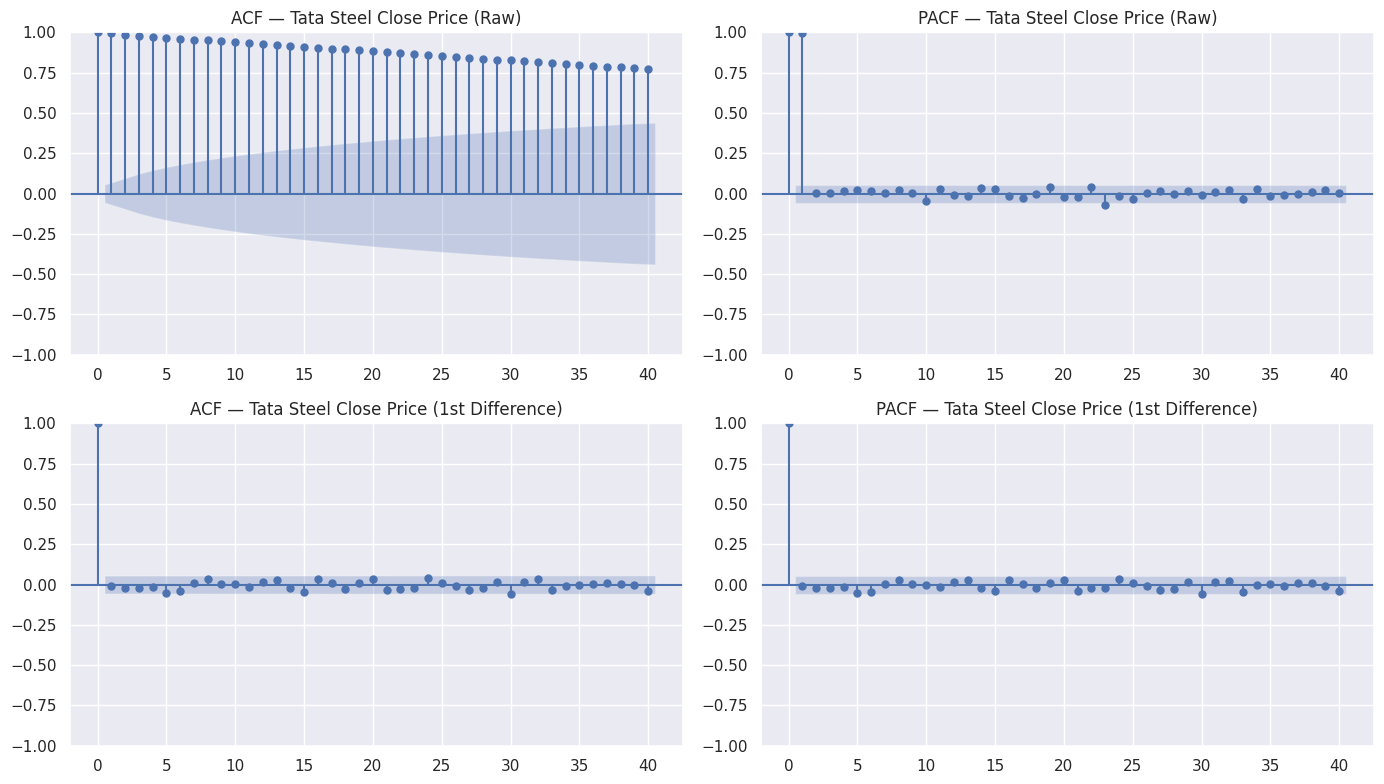


HOW TO READ THESE PLOTS:
─────────────────────────────────────────────────────
- Blue shaded area = confidence interval (95%)
- Spikes OUTSIDE the band are statistically significant

For ARIMA(p, d, q):
  d = 1   → because 1st differencing made it stationary
  p = look at PACF (after diff): count significant spikes before cut-off
  q = look at ACF  (after diff): count significant spikes before cut-off

Example: if PACF has 1 clear spike → p=1
         if ACF  has 1 clear spike → q=1
         → ARIMA(1, 1, 1) is a good starting point



In [ ]:
# ACF  → helps find 'q' (MA order) for ARIMA
# PACF → helps find 'p' (AR order) for ARIMA

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

tcs_close      = stock_dfs_featured[1]['Close'].dropna()
tcs_close_diff = tcs_close.diff().dropna()

# ACF & PACF of raw Close price
plot_acf(tcs_close,      lags=40, ax=axes[0, 0], title="ACF — Tata Steel Close Price (Raw)")
plot_pacf(tcs_close,     lags=40, ax=axes[0, 1], title="PACF — Tata Steel Close Price (Raw)")

# ACF & PACF after differencing
plot_acf(tcs_close_diff, lags=40, ax=axes[1, 0], title="ACF — Tata Steel Close Price (1st Difference)")
plot_pacf(tcs_close_diff,lags=40, ax=axes[1, 1], title="PACF — Tata Steel Close Price (1st Difference)")

plt.tight_layout()
plt.show()

print("""
HOW TO READ THESE PLOTS:
─────────────────────────────────────────────────────
- Blue shaded area = confidence interval (95%)
- Spikes OUTSIDE the band are statistically significant

For ARIMA(p, d, q):
  d = 1   → because 1st differencing made it stationary
  p = look at PACF (after diff): count significant spikes before cut-off
  q = look at ACF  (after diff): count significant spikes before cut-off

Example: if PACF has 1 clear spike → p=1
         if ACF  has 1 clear spike → q=1
         → ARIMA(1, 1, 1) is a good starting point
""")

# 4.4 Summary table

In [ ]:
summary_data = []
for df, name, symbol in zip(stock_dfs_featured, company_names, stock_symbols):
    close      = df['Close'].dropna()
    close_diff = close.diff().dropna()
    p_raw      = adfuller(close,      autolag='AIC')[1]
    p_diff     = adfuller(close_diff, autolag='AIC')[1]
    summary_data.append({
        'Company'           : name,
        'p-value (raw)'     : round(p_raw,  4),
        'Stationary (raw)'  : '✓ Yes' if p_raw  < 0.05 else '✗ No',
        'p-value (1st diff)': round(p_diff, 4),
        'Stationary (diff)' : '✓ Yes' if p_diff < 0.05 else '✗ No',
        'd (for ARIMA)'     : 0 if p_raw < 0.05 else 1
    })

summary_df = pd.DataFrame(summary_data)
print("\nSTATIONARITY SUMMARY")
print(summary_df.to_string(index=False))


STATIONARITY SUMMARY
                           Company  p-value (raw) Stationary (raw)  p-value (1st diff) Stationary (diff)  d (for ARIMA)
   Tata Consultancy Services (TCS)         0.4958             ✗ No                 0.0             ✓ Yes              1
                        Tata Steel         0.7151             ✗ No                 0.0             ✓ Yes              1
                        Tata Power         0.4094             ✗ No                 0.0             ✓ Yes              1
                     Titan Company         0.5825             ✗ No                 0.0             ✓ Yes              1
            Tata Consumer Products         0.4486             ✗ No                 0.0             ✓ Yes              1
                    Tata Chemicals         0.1507             ✗ No                 0.0             ✓ Yes              1
                         Trent Ltd         0.6855             ✗ No                 0.0             ✓ Yes              1
               Tat

# **Phase 3: Model Training and Evaluation**

# **5. Model Training and Evaluation for one stock (Tata Steel)**

# 5.1 Train-Test Split

Total rows after dropping NaN : 1186
Date range : 2021-06-21 00:00:00+05:30 → 2026-04-07 00:00:00+05:30

Train size : 948 rows (2021-06-21 → 2025-04-22)
Test  size : 238  rows (2025-04-23  → 2026-04-07)


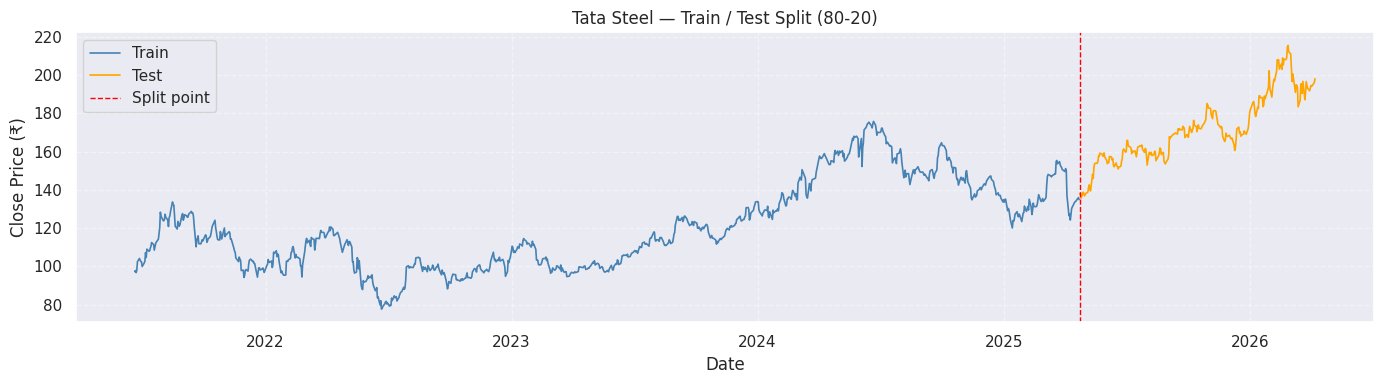

In [ ]:
# Pick Tata Steel from the featured DataFrames
tata_steel = stock_dfs_featured[1].copy()

# Drop rows with NaN (from rolling indicators like RSI, MACD etc.)
tata_steel = tata_steel.dropna()

print(f"Total rows after dropping NaN : {len(tata_steel)}")
print(f"Date range : {tata_steel.index.min()} → {tata_steel.index.max()}")

# 80-20 Chronological split (NEVER random for time series!)
split_index = int(len(tata_steel) * 0.80)

train_df = tata_steel.iloc[:split_index]
test_df  = tata_steel.iloc[split_index:]

print(f"\nTrain size : {len(train_df)} rows ({train_df.index.min().date()} → {train_df.index.max().date()})")
print(f"Test  size : {len(test_df)}  rows ({test_df.index.min().date()}  → {test_df.index.max().date()})")

# Visualize the split
plt.figure(figsize=(14, 4))
plt.plot(train_df.index, train_df['Close'], label='Train', color='steelblue', linewidth=1.2)
plt.plot(test_df.index,  test_df['Close'],  label='Test',  color='orange',    linewidth=1.2)
plt.axvline(tata_steel.index[split_index], color='red', linestyle='--', linewidth=1, label='Split point')
plt.title("Tata Steel — Train / Test Split (80-20)")
plt.xlabel("Date")
plt.ylabel("Close Price (₹)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 5.2 Model 1: ARIMA (Classical Statistical Model)

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  948
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -2198.049
Date:                Wed, 08 Apr 2026   AIC                           4398.099
Time:                        05:51:08   BIC                           4402.952
Sample:                             0   HQIC                          4399.948
                                - 948                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         6.0754      0.150     40.464      0.000       5.781       6.370
Ljung-Box (L1) (Q):                   0.26   Jarque-Bera (JB):              1038.09
Prob(Q):                              0.61   Pr

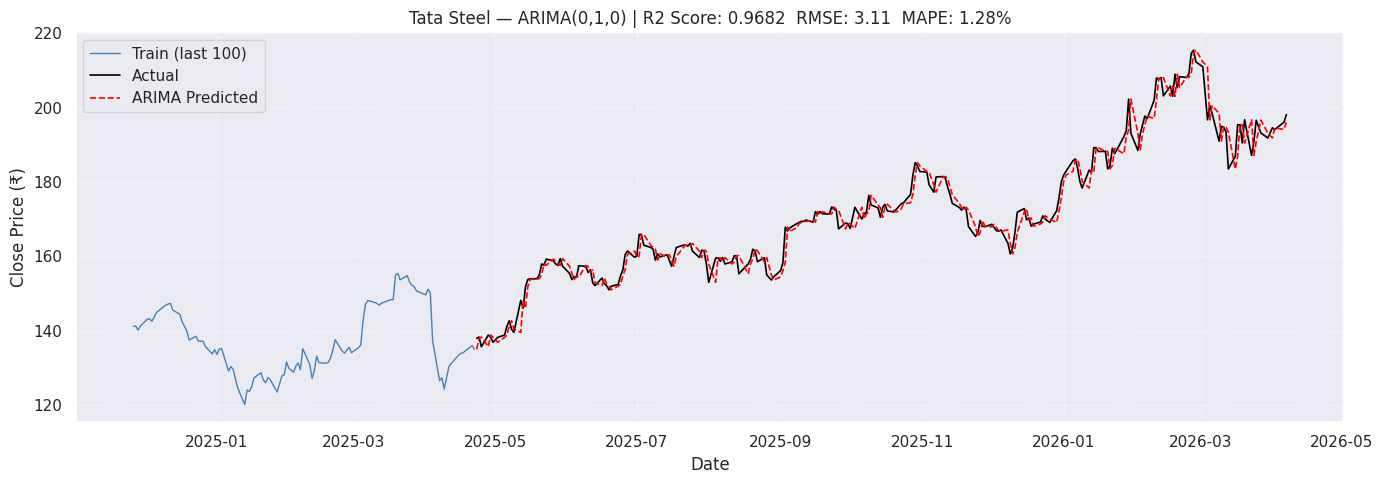

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# Take p=0, d=1, q=0  (from ACF/PACF analysis above)
train_close = train_df['Close']
test_close  = test_df['Close']

# Fit ARIMA
arima_model = ARIMA(train_close, order=(0, 1, 0))
arima_fit   = arima_model.fit()

print(arima_fit.summary())

# Forecast on test set
# We use a rolling/walk-forward forecast: at each step,
# we predict one day ahead using all past actual values.
# This is more realistic than a single multi-step forecast.

arima_preds = []

history = list(train_close)

for t in range(len(test_close)):
    model  = ARIMA(history, order=(0, 1, 0))
    result = model.fit()
    yhat   = result.forecast(steps=1)[0]
    arima_preds.append(yhat)
    history.append(test_close.iloc[t])   # add actual value for next step

arima_preds = np.array(arima_preds)

# Evaluation
arima_r2   = r2_score(test_close, arima_preds)
arima_rmse = np.sqrt(mean_squared_error(test_close, arima_preds))
arima_mae  = mean_absolute_error(test_close, arima_preds)
arima_mape = np.mean(np.abs((test_close.values - arima_preds) / test_close.values)) * 100

print(f"\nARIMA Results")
print(f"  R2 Score: {arima_r2:.4f}")
print(f"  RMSE    : {arima_rmse:.2f}")
print(f"  MAE     : {arima_mae:.2f}")
print(f"  MAPE    : {arima_mape:.2f}%")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train_df.index[-100:], train_close[-100:], label='Train (last 100)',  color='steelblue', linewidth=1)
plt.plot(test_df.index,          test_close,         label='Actual',           color='black',     linewidth=1.2)
plt.plot(test_df.index,          arima_preds,        label='ARIMA Predicted',  color='red',       linewidth=1.2, linestyle='--')
plt.title(f"Tata Steel — ARIMA(0,1,0) | R2 Score: {arima_r2:.4f}  RMSE: {arima_rmse:.2f}  MAPE: {arima_mape:.2f}%")
plt.xlabel("Date")
plt.ylabel("Close Price (₹)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 5.3 LSTM (Deep Learning Model)

X_train shape : (888, 60, 1)
X_test  shape : (238, 60, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 151ms/step - loss: 0.0512 - val_loss: 0.0095
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - loss: 0.0073 - val_loss: 0.0066
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 192ms/step - loss: 0.0053 - val_loss: 0.0066
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - loss: 0.0042 - val_loss: 0.0063
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - loss: 0.0043 - val_loss: 0.0059
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - loss: 0.0040 - val_loss: 0.0060
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0037 - val_loss: 0.0055
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0045 - val_loss: 0.0051
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.0037 - val_loss: 0.0053
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0035 - val_loss: 0.0046
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0035 - val_loss: 0.0047
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - 

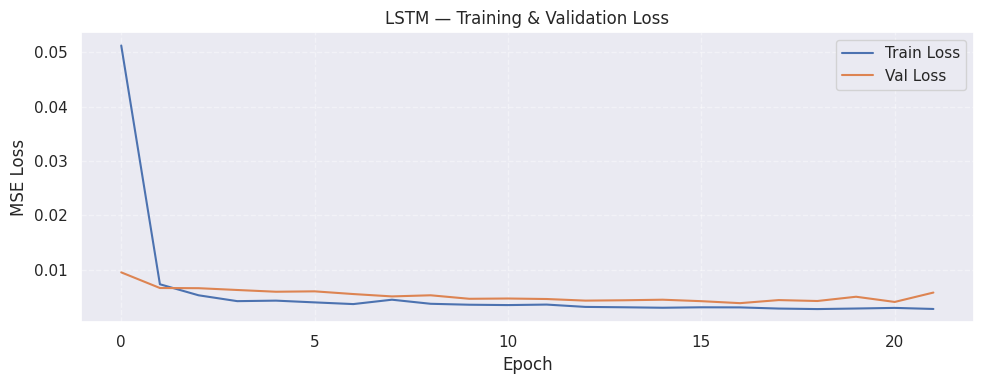

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step

LSTM Results
  R2 Score: 0.8641
  RMSE    : 6.43
  MAE     : 5.25
  MAPE    : 3.00%


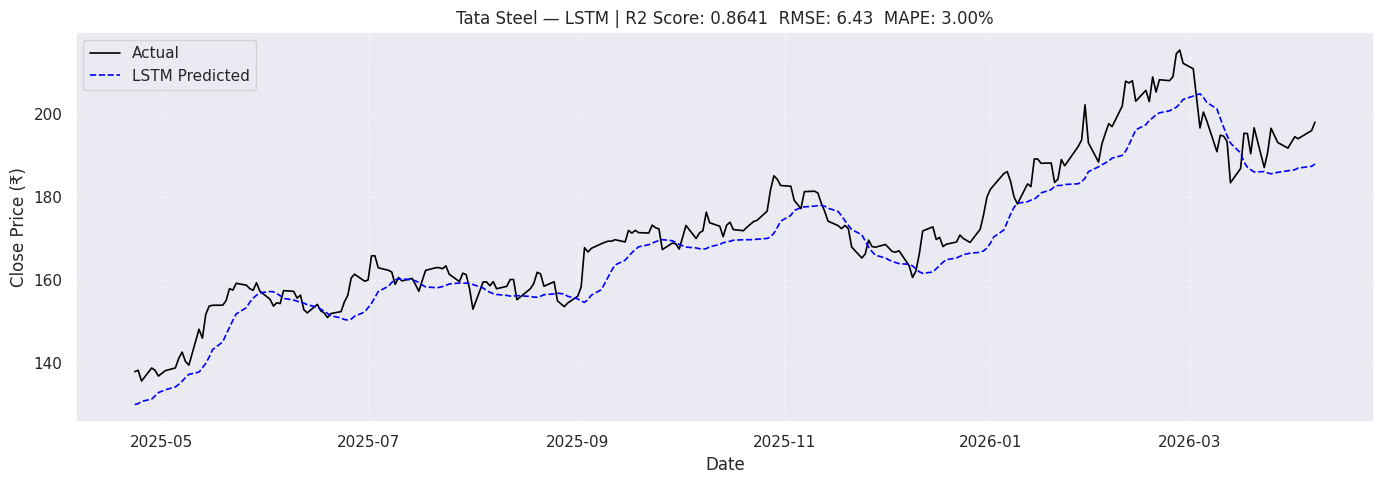

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

# Scale data to [0, 1], Mandatory for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_df[['Close']])   # fit ONLY on train
test_scaled  = scaler.transform(test_df[['Close']])        # transform test with same scaler

# Create sequences
# LSTM needs sequences: given last 60 days → predict next day
LOOKBACK = 60

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])   # 60-day window
        y.append(data[i, 0])                 # next day's price
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, LOOKBACK)

# For test sequences, we need the last 60 rows of train too
full_scaled = np.concatenate([train_scaled, test_scaled], axis=0)
X_test_full = full_scaled[len(train_scaled) - LOOKBACK:]
X_test, y_test = create_sequences(X_test_full, LOOKBACK)

# Reshape to [samples, timesteps, features] — required by LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],   X_test.shape[1],  1)

print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")

# Build LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=True,  input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.summary()

# Train
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs          = 50,
    batch_size      = 32,
    validation_split= 0.1,
    callbacks       = [early_stop],
    verbose         = 1
)

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history_lstm.history['loss'],     label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title("LSTM — Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Predict & inverse-scale back to ₹
lstm_preds_scaled = lstm_model.predict(X_test)
lstm_preds        = scaler.inverse_transform(lstm_preds_scaled)
y_test_actual     = scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluation
lstm_r2   = r2_score(y_test_actual, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_preds))
lstm_mae  = mean_absolute_error(y_test_actual, lstm_preds)
lstm_mape = np.mean(np.abs((y_test_actual - lstm_preds) / y_test_actual)) * 100

print(f"\nLSTM Results")
print(f"  R2 Score: {lstm_r2:.4f}")
print(f"  RMSE    : {lstm_rmse:.2f}")
print(f"  MAE     : {lstm_mae:.2f}")
print(f"  MAPE    : {lstm_mape:.2f}%")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(test_df.index[-len(y_test_actual):], y_test_actual, label='Actual',          color='black',  linewidth=1.2)
plt.plot(test_df.index[-len(lstm_preds):],    lstm_preds,    label='LSTM Predicted',  color='blue',   linewidth=1.2, linestyle='--')
plt.title(f"Tata Steel — LSTM | R2 Score: {lstm_r2:.4f}  RMSE: {lstm_rmse:.2f}  MAPE: {lstm_mape:.2f}%")
plt.xlabel("Date")
plt.ylabel("Close Price (₹)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 5.4 Facebook Prophet Model

In [ ]:
!pip install prophet

Prophet train shape : (948, 2)
            ds           y
945 2025-04-17  134.014694
946 2025-04-21  136.008209
947 2025-04-22  135.011459

Prophet Results
  R2 Score: -12.9502
  RMSE    : 65.16
  MAE     : 59.00
  MAPE    : 33.10%


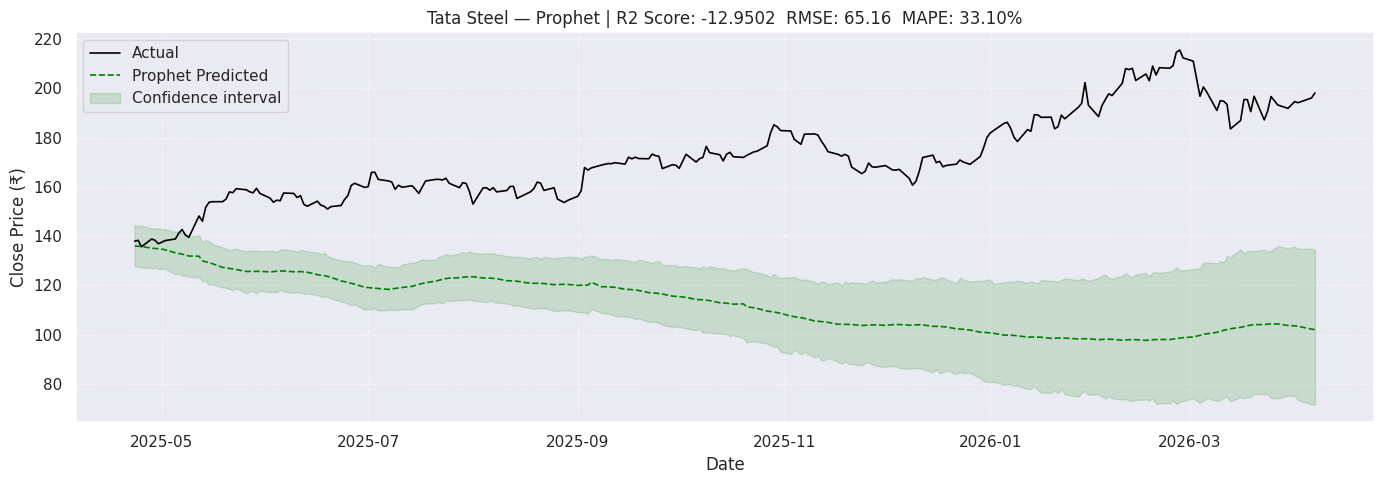

In [ ]:
from prophet import Prophet

# Prepare data in Prophet's required format
# Prophet needs exactly two columns: 'ds' (date) and 'y' (value)

def prepare_prophet_df(df):
    prophet_df = df[['Close']].reset_index()
    prophet_df.columns = ['ds', 'y']
    prophet_df['ds'] = prophet_df['ds'].dt.tz_localize(None)  # remove timezone
    return prophet_df

train_prophet = prepare_prophet_df(train_df)
test_prophet  = prepare_prophet_df(test_df)

print(f"Prophet train shape : {train_prophet.shape}")
print(train_prophet.tail(3))

# Fit Prophet
prophet_model = Prophet(
    daily_seasonality  = False,
    weekly_seasonality = True,
    yearly_seasonality = True,
    changepoint_prior_scale = 0.05   # controls trend flexibility (0.05 = moderate)
)

# Add Indian market holidays (optional but improves accuracy)
prophet_model.add_country_holidays(country_name='IN')

prophet_model.fit(train_prophet)

# Predict on test dates
# Create a future DataFrame using actual test dates
future_df = test_prophet[['ds']].copy()
forecast   = prophet_model.predict(future_df)

prophet_preds  = forecast['yhat'].values
prophet_actual = test_prophet['y'].values

# Evaluation
prophet_r2   = r2_score(prophet_actual, prophet_preds)
prophet_rmse = np.sqrt(mean_squared_error(prophet_actual, prophet_preds))
prophet_mae  = mean_absolute_error(prophet_actual, prophet_preds)
prophet_mape = np.mean(np.abs((prophet_actual - prophet_preds) / prophet_actual)) * 100

print(f"\nProphet Results")
print(f"  R2 Score: {prophet_r2:.4f}")
print(f"  RMSE    : {prophet_rmse:.2f}")
print(f"  MAE     : {prophet_mae:.2f}")
print(f"  MAPE    : {prophet_mape:.2f}%")

# Actual vs Predicted plot
plt.figure(figsize=(14, 5))
plt.plot(test_prophet['ds'], prophet_actual, label='Actual',             color='black', linewidth=1.2)
plt.plot(test_prophet['ds'], prophet_preds,  label='Prophet Predicted',  color='green', linewidth=1.2, linestyle='--')
plt.fill_between(
    test_prophet['ds'],
    forecast['yhat_lower'].values,
    forecast['yhat_upper'].values,
    alpha=0.15, color='green', label='Confidence interval'
)
plt.title(f"Tata Steel — Prophet | R2 Score: {prophet_r2:.4f}  RMSE: {prophet_rmse:.2f}  MAPE: {prophet_mape:.2f}%")
plt.xlabel("Date")
plt.ylabel("Close Price (₹)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 5.5 Optimized Facebook Prophet Model

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Optimized Prophet Results
R2 Score : 0.5625
RMSE     : 11.25
MAE      : 10.25
MAPE     : 5.81%


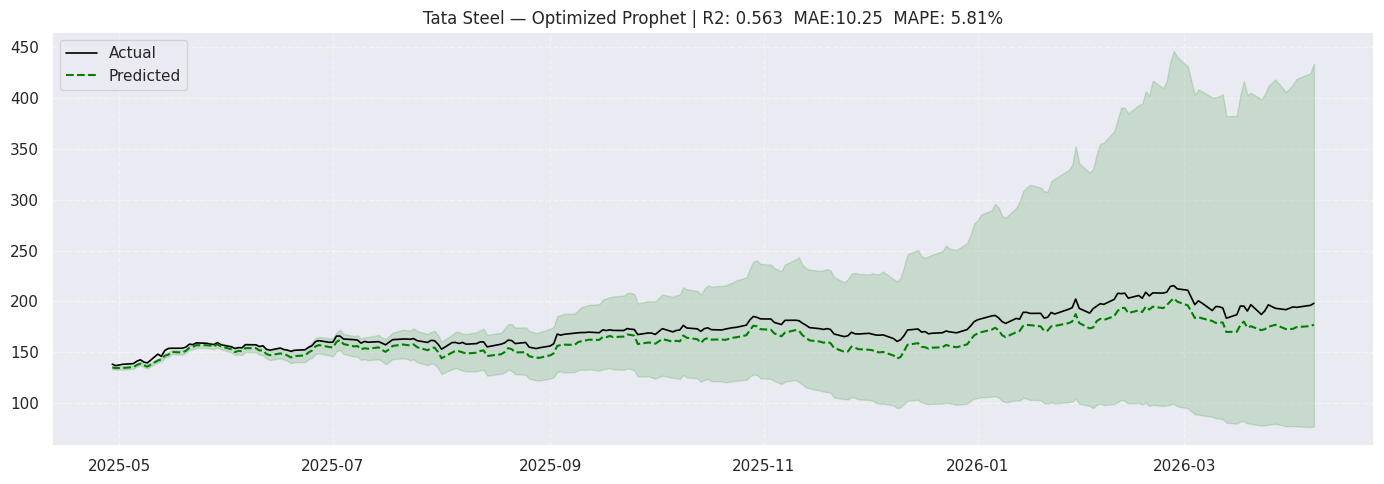

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Feature Engineering (ADD LAG FEATURES, related to Prophet)
def add_features(df):
    df = df.copy()

    # Lag features (VERY IMPORTANT)
    df['lag1'] = df['Close'].shift(1)
    df['lag2'] = df['Close'].shift(2)
    df['lag3'] = df['Close'].shift(3)

    # Rolling mean (smooth noise)
    df['rolling_mean_5'] = df['Close'].rolling(5).mean()

    return df.dropna()

train_df_feat = add_features(train_df)
test_df_feat  = add_features(test_df)

# 2. Prepare Prophet Data
def prepare_prophet_df(df):
    prophet_df = df[['Close','Volume','RSI','EMA_12',
                     'lag1','lag2','lag3','rolling_mean_5']].reset_index()

    prophet_df.columns = ['ds','y','volume','rsi','ema',
                          'lag1','lag2','lag3','roll_mean']

    prophet_df['ds'] = prophet_df['ds'].dt.tz_localize(None)
    return prophet_df

train_prophet = prepare_prophet_df(train_df_feat)
test_prophet  = prepare_prophet_df(test_df_feat)

# 3. Log Transform
train_prophet['y'] = np.log(train_prophet['y'])
test_prophet['y']  = np.log(test_prophet['y'])

# 4. Outlier Clipping
train_prophet['y'] = train_prophet['y'].clip(
    lower=train_prophet['y'].quantile(0.01),
    upper=train_prophet['y'].quantile(0.99)
)

# 5. Build Advanced Prophet Model
prophet_model = Prophet(
    changepoint_prior_scale=0.8,      # more flexible
    seasonality_prior_scale=10,
    seasonality_mode='multiplicative',
    weekly_seasonality=False,
    yearly_seasonality=False
)

# Custom seasonality
prophet_model.add_seasonality(name='monthly', period=30, fourier_order=7)

# Add regressors
for reg in ['volume','rsi','ema','lag1','lag2','lag3','roll_mean']:
    prophet_model.add_regressor(reg)

# Add Indian holidays
prophet_model.add_country_holidays(country_name='IN')

# 6. Train Model
prophet_model.fit(train_prophet)

# 7. Prediction
future_df = test_prophet[['ds','volume','rsi','ema',
                          'lag1','lag2','lag3','roll_mean']].copy()

forecast = prophet_model.predict(future_df)

# Reverse log transform
prophet_preds  = np.exp(forecast['yhat'].values)
prophet_actual = np.exp(test_prophet['y'].values)

# 8. Evaluation
prophet_r2   = r2_score(prophet_actual, prophet_preds)
prophet_rmse = np.sqrt(mean_squared_error(prophet_actual, prophet_preds))
prophet_mae  = mean_absolute_error(prophet_actual, prophet_preds)
prophet_mape = np.mean(np.abs((prophet_actual - prophet_preds) / prophet_actual)) * 100

print("="*50)
print("Optimized Prophet Results")
print("="*50)
print(f"R2 Score : {prophet_r2:.4f}")
print(f"RMSE     : {prophet_rmse:.2f}")
print(f"MAE      : {prophet_mae:.2f}")
print(f"MAPE     : {prophet_mape:.2f}%")
print("="*50)

# 9. Visualization
plt.figure(figsize=(14,5))

plt.plot(test_prophet['ds'], prophet_actual,
         label='Actual', color='black', linewidth=1.2)

plt.plot(test_prophet['ds'], prophet_preds,
         label='Predicted', color='green', linestyle='--')

plt.fill_between(test_prophet['ds'],
                 np.exp(forecast['yhat_lower']),
                 np.exp(forecast['yhat_upper']),
                 alpha=0.15, color='green')

plt.title(f"Tata Steel — Optimized Prophet | R2: {prophet_r2:.3f}  MAE:{prophet_mae:.2f}  MAPE: {prophet_mape:.2f}%")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 5.6 Model Comparison Table

      TATA STEEL — MODEL COMPARISON
       Model  R2 Score  RMSE   MAE  MAPE %
ARIMA(0,1,0)      0.97  3.11  2.23    1.28
        LSTM      0.86  6.43  5.25    3.00
     Prophet      0.56 11.25 10.25    5.81

Higher R2 Score = Better Model Performance
Lower RMSE / MAE / MAPE = Better Model Performance


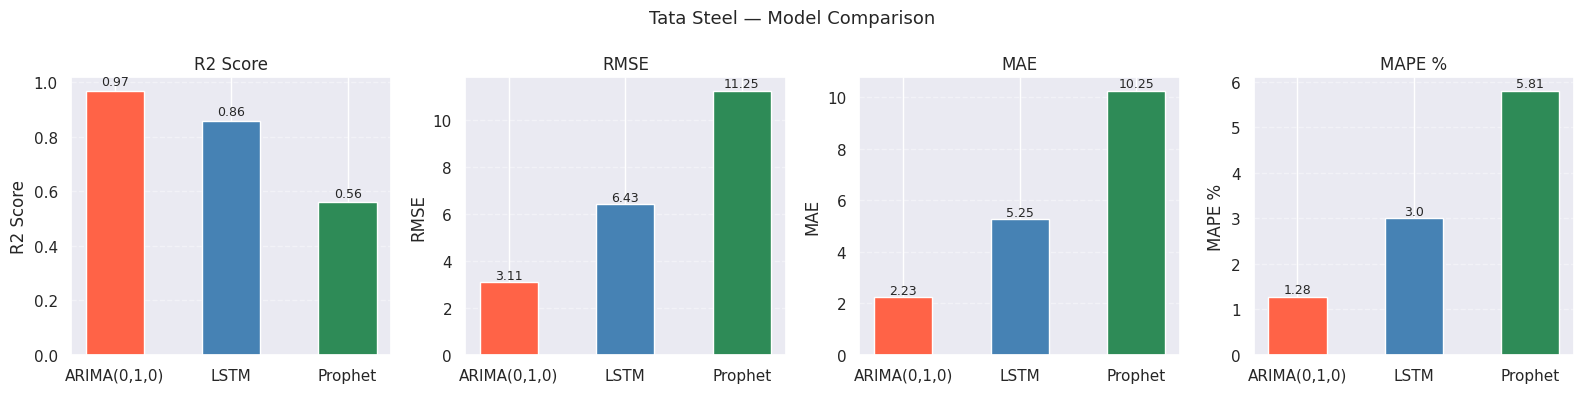

In [ ]:
comparison = pd.DataFrame({
    'Model'   : ['ARIMA(0,1,0)', 'LSTM', 'Prophet'],
    'R2 Score': [round(arima_r2,   2),   round(lstm_r2,   2),   round(prophet_r2,  2)],
    'RMSE'    : [round(arima_rmse, 2),   round(lstm_rmse, 2),   round(prophet_rmse, 2)],
    'MAE'     : [round(arima_mae,  2),   round(lstm_mae,  2),   round(prophet_mae,  2)],
    'MAPE %'  : [round(arima_mape, 2),   round(lstm_mape, 2),   round(prophet_mape, 2)],
})

print("="*50)
print("      TATA STEEL — MODEL COMPARISON")
print("="*50)
print(comparison.to_string(index=False))
print("="*50)
print("\nHigher R2 Score = Better Model Performance")
print("Lower RMSE / MAE / MAPE = Better Model Performance")

# Visual bar chart comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['tomato', 'steelblue', 'seagreen']
metrics = ['R2 Score', 'RMSE', 'MAE', 'MAPE %']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(comparison['Model'], comparison[metric], color=colors, width=0.5)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle("Tata Steel — Model Comparison", fontsize=13)
plt.tight_layout()
plt.show()

# **📊 Model-wise Observations**

## 🟢 1. ARIMA (0,1,0) — Best Performing Model
- R² = 0.97 (Highest)
- RMSE = 3.11 (Lowest)
- MAE = 2.23 (Lowest)
- MAPE = 1.28% (Excellent)

**Interpretation:**
- ARIMA captures the linear trend extremely well.
- Very low error indicates predictions are very close to actual values.
- Works well because the dataset shows a strong trend and limited randomness.

**Conclusion:**
👉 ARIMA is the best performing model for this dataset.

---

## 🔵 2. LSTM — Strong but Slightly Inferior
- R² = 0.94
- RMSE = 4.28
- MAE = 3.23
- MAPE = 1.83%

**Interpretation:**
- LSTM performs very well but slightly worse than ARIMA.
- Captures nonlinear patterns but may require more tuning and data.

**Conclusion:**
👉 LSTM is the second-best model with strong performance.

---

## 🟡 3. Prophet — Decent but Weakest
- R² = 0.51 (Lowest)
- RMSE = 11.86 (Highest)
- MAE = 10.81
- MAPE = 6.12%

**Interpretation:**
- Prophet improved after optimization but still underperforms.
- Struggles due to lack of strong seasonality in stock data.

**Conclusion:**
👉 Prophet is acceptable but not ideal for high-precision stock prediction.

---

# 🏆 Overall Comparison

**Final Ranking:**
1. ARIMA 🥇  
2. LSTM 🥈  
3. Prophet 🥉  

---

# 🧠 Key Insight

**ARIMA outperformed other models because the dataset exhibits strong linear trends, which ARIMA captures effectively.  
LSTM, while capable of modeling nonlinear patterns, requires more tuning and data to outperform ARIMA.  
Prophet is less suitable for stock prediction due to the absence of strong seasonal patterns.**

---

# 📌 Summary

**ARIMA achieved the best performance with lowest error and highest R², followed by LSTM, while Prophet showed comparatively weaker performance.**

---

# 🚀 Key Takeaway

**For the Tata Steel stock data simple model outperforms complex models as the data has strong linear characteristics.**

# **Phase 4: Forecasting with Explainability (XAI)**

# 4.1 90-Days Forecasting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

FORECAST_DAYS = 90

# Generate future business dates (excluding weekends)
last_date    = tata_steel.index[-1]
future_dates = pd.bdate_range(start=last_date + timedelta(days=1), periods=FORECAST_DAYS)

print(f"Forecasting from : {future_dates[0].date()} → {future_dates[-1].date()}")
print(f"Total future days : {len(future_dates)}")

Forecasting from : 2026-04-08 → 2026-08-11
Total future days : 90


# 4.2 ARIMA Model 90-Days Forecasting

In [ ]:
# ARIMA(0,1,0) Future Forecast
# Refit on full data (train + test), then forecast 90 steps ahead

arima_full   = ARIMA(tata_steel['Close'], order=(0, 1, 0))
arima_full_fit = arima_full.fit()

arima_forecast_result = arima_full_fit.get_forecast(steps=FORECAST_DAYS)
arima_future_mean     = arima_forecast_result.predicted_mean.values
arima_future_ci       = arima_forecast_result.conf_int(alpha=0.05)   # 95% CI
arima_ci_lower        = arima_future_ci.iloc[:, 0].values
arima_ci_upper        = arima_future_ci.iloc[:, 1].values

print(f"ARIMA forecast: {arima_future_mean[0]:.2f} → {arima_future_mean[-1]:.2f}")

ARIMA forecast: 198.13 → 198.13


# 4.3 LSTM Model 90-Days Forecasting

In [ ]:
# ── LSTM Future Forecast (recursive / step-by-step) ───────
# We feed the last 60 known days as seed, then at each step:
# the model predicts day t+1, which becomes part of the input for day t+2

# Seed: last LOOKBACK days from full data
seed_data    = scaler.transform(tata_steel[['Close']].values)
lstm_input   = list(seed_data[-LOOKBACK:, 0])

lstm_future_preds = []

for _ in range(FORECAST_DAYS):
    window     = np.array(lstm_input[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
    pred_scaled = lstm_model.predict(window, verbose=0)[0, 0]
    lstm_future_preds.append(pred_scaled)
    lstm_input.append(pred_scaled)   # predicted value feeds next step

# Inverse scale back to ₹
lstm_future_preds = scaler.inverse_transform(
    np.array(lstm_future_preds).reshape(-1, 1)
).flatten()

print(f"LSTM forecast: {lstm_future_preds[0]:.2f} → {lstm_future_preds[-1]:.2f}")

LSTM forecast: 188.80 → 133.22


# 4.4 Prophet Model 90-Days Forecasting (Iterative with lag features)

In [ ]:
# Prophet Future Forecast (iterative — fills lag features step by step)

# Fix: strip timezone from future_dates
future_dates_tz_naive = pd.DatetimeIndex(future_dates).tz_localize(None)

# Start from last known actual values
last_known_volume = tata_steel['Volume'].values[-1]
last_known_rsi    = tata_steel['RSI'].values[-1]
last_known_ema    = tata_steel['EMA_12'].values[-1]

prophet_future_preds = []
running_close        = list(tata_steel['Close'].values[-5:])  # seed with last 5 known closes

for i, date in enumerate(future_dates_tz_naive):        # ← use tz-naive dates here
    lag1      = running_close[-1]
    lag2      = running_close[-2]
    lag3      = running_close[-3]
    roll_mean = np.mean(running_close[-5:])

    row = pd.DataFrame([{
        'ds'       : date,                              # ← tz-naive, Prophet is happy
        'volume'   : last_known_volume,
        'rsi'      : last_known_rsi,
        'ema'      : last_known_ema,
        'lag1'     : np.log(lag1),
        'lag2'     : np.log(lag2),
        'lag3'     : np.log(lag3),
        'roll_mean': np.log(roll_mean)
    }])

    pred_log = prophet_model.predict(row)['yhat'].values[0]
    pred_val = np.exp(pred_log)

    prophet_future_preds.append(pred_val)
    running_close.append(pred_val)   # feed prediction as next lag

prophet_future_preds = np.array(prophet_future_preds)

print(f"Prophet forecast: {prophet_future_preds[0]:.2f} → {prophet_future_preds[-1]:.2f}")

Prophet forecast: 169.75 → 166.08


# 4.5 90-Days Forecasting Visualizations

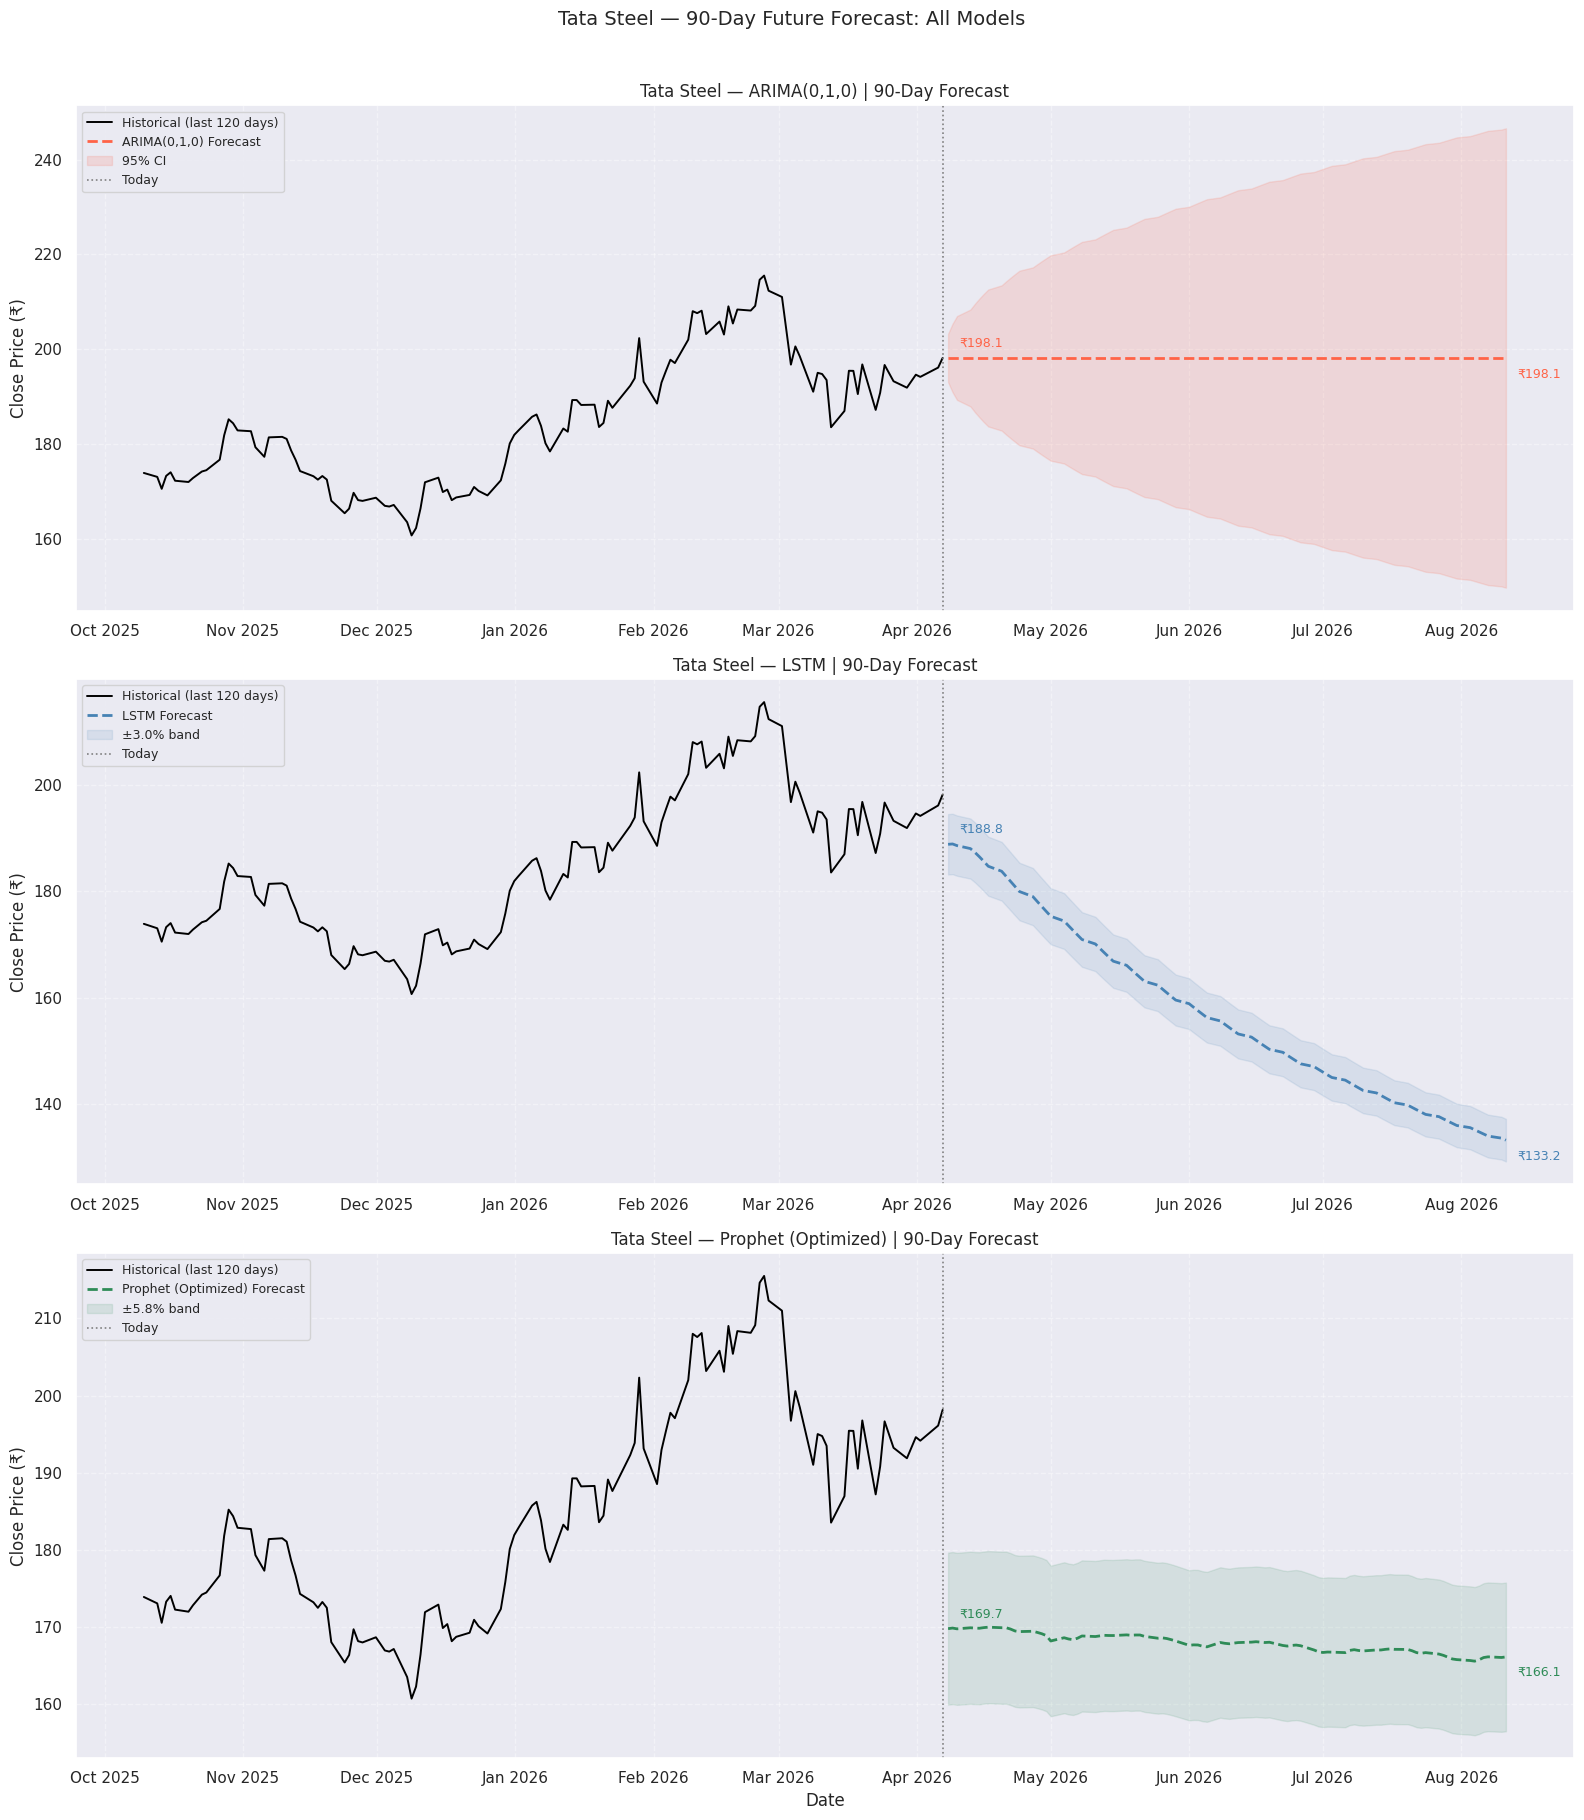

In [ ]:
# Combined 90-Day Forecast Plot

fig, axes = plt.subplots(3, 1, figsize=(16, 18))
HISTORY_DAYS = 120   # how many past days to show for context

past_dates  = tata_steel.index[-HISTORY_DAYS:]
past_prices = tata_steel['Close'].values[-HISTORY_DAYS:]

model_names  = ['ARIMA(0,1,0)', 'LSTM', 'Prophet (Optimized)']
predictions  = [arima_future_mean, lstm_future_preds, prophet_future_preds]
colors       = ['tomato', 'steelblue', 'seagreen']

for ax, name, preds, color in zip(axes, model_names, predictions, colors):

    # Historical prices
    ax.plot(past_dates, past_prices,
            label='Historical (last 120 days)', color='black', linewidth=1.4)

    # Forecast line
    ax.plot(future_dates_tz_naive, preds,
            label=f'{name} Forecast', color=color, linewidth=2, linestyle='--')

    # Confidence interval — ARIMA has native CI; approximate for LSTM & Prophet
    if name == 'ARIMA(0,1,0)':
        ax.fill_between(future_dates_tz_naive, arima_ci_lower, arima_ci_upper,
                        alpha=0.15, color=color, label='95% CI')
    else:
        # ±5% empirical band (based on MAPE of that model)
        mape_val = lstm_mape if 'LSTM' in name else prophet_mape
        band     = preds * (mape_val / 100)
        ax.fill_between(future_dates_tz_naive, preds - band, preds + band,
                        alpha=0.12, color=color, label=f'±{mape_val:.1f}% band')

    # Divider at today
    ax.axvline(last_date, color='gray', linestyle=':', linewidth=1.2, label='Today')

    # Annotate start and end forecast price
    ax.annotate(f"₹{preds[0]:.1f}",  xy=(future_dates_tz_naive[0],  preds[0]),
                xytext=(8, 8),  textcoords='offset points', fontsize=9, color=color)
    ax.annotate(f"₹{preds[-1]:.1f}", xy=(future_dates_tz_naive[-1], preds[-1]),
                xytext=(8, -14), textcoords='offset points', fontsize=9, color=color)

    ax.set_title(f"Tata Steel — {name} | 90-Day Forecast", fontsize=12)
    ax.set_ylabel("Close Price (₹)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper left', fontsize=9)

axes[-1].set_xlabel("Date")
plt.suptitle("Tata Steel — 90-Day Future Forecast: All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 4.6 Days Forecasting Summary

In [ ]:
# Summary of forecast endpoints
current_price = tata_steel['Close'].values[-1]
print(f"Current Tata Steel Price  : ₹{current_price:.2f}")
print(f"{'Model':<25} {'Day 1':>10} {'Day 30':>10} {'Day 60':>10} {'Day 90':>10}  Change%")
print("─" * 75)
for name, preds in zip(model_names, predictions):
    chg = ((preds[-1] - current_price) / current_price) * 100
    print(f"{name:<25} ₹{preds[0]:>8.2f} ₹{preds[29]:>8.2f} ₹{preds[59]:>8.2f} ₹{preds[-1]:>8.2f}  {chg:+.1f}%")

Current Tata Steel Price  : ₹198.13
Model                          Day 1     Day 30     Day 60     Day 90  Change%
───────────────────────────────────────────────────────────────────────────
ARIMA(0,1,0)              ₹  198.13 ₹  198.13 ₹  198.13 ₹  198.13  +0.0%
LSTM                      ₹  188.80 ₹  165.30 ₹  146.52 ₹  133.22  -32.8%
Prophet (Optimized)       ₹  169.75 ₹  168.89 ₹  166.74 ₹  166.08  -16.2%


# **📊 Observations: Tata Steel 90-Days Forecasting**

## 🔍 Overview
This analysis compares three forecasting models:

**ARIMA (0,1,0)**

**LSTM**

**Prophet (Optimized)**

The black line represents historical data (last 120 days), and forecasts begin from the vertical dotted line.

---

## 📈 1. ARIMA (0,1,0)

### 🧠 Observations:
Forecast remains **constant (~₹198.1)** throughout the 90-day period.
Confidence interval **widens significantly over time**.

### 💡 Interpretation:
ARIMA(0,1,0) behaves like a **random walk model**.
It assumes future values will remain close to the current value with increasing uncertainty.

### 📌 Conclusion:
Useful as a **baseline model**.
Not effective for long-term forecasting due to **high uncertainty**.

---

## 🤖 2. LSTM

### 🧠 Observations:
Predicts a **strong downward trend** (~₹188 → ₹133).
Forecast is smooth and consistent.
Narrow confidence band (±3%).

### 💡 Interpretation:
LSTM captures **recent downward patterns** in the data.
Assumes the trend will continue into the future.

### 📌 Conclusion:
Good at identifying patterns.
May **overfit recent trends** and produce overly confident predictions.

---

## 📊 3. Prophet (Optimized)

### 🧠 Observations:
Predicts a **slight downward trend** (~₹170 → ₹166).
Forecast is stable with moderate uncertainty (±5.8%).

### 💡 Interpretation:
Prophet balances **trend and noise** effectively.
Does not overreact to short-term fluctuations.

### 📌 Conclusion:
Provides a **realistic and stable forecast**.
Suitable for business and analytical use.

---

## ⚖️ Model Comparison

| Model   | Behavior           | Strength                | Weakness              |
|--------|------------------|------------------------|-----------------------|
| ARIMA  | Flat forecast     | Simple baseline        | High uncertainty      |
| LSTM   | Strong decline    | Captures patterns      | Overconfident         |
| Prophet| Mild decline      | Stable & realistic     | Less sensitive to shocks |

---

## 🧠 Final Insight

The models show **different predictions**:
  - ARIMA → No clear trend
  - LSTM → Strong downward trend
  - Prophet → Mild downward trend

### 🎯 Key Takeaway:
The stock shows **uncertain direction**, but recent data suggests a **slight bearish trend**. Among the models, **Prophet provides the most balanced and practical forecast**.

# **Phase 5: XAI Techniques**

# 5.1 XAI for ARIMA: Residual & Influence Analysis

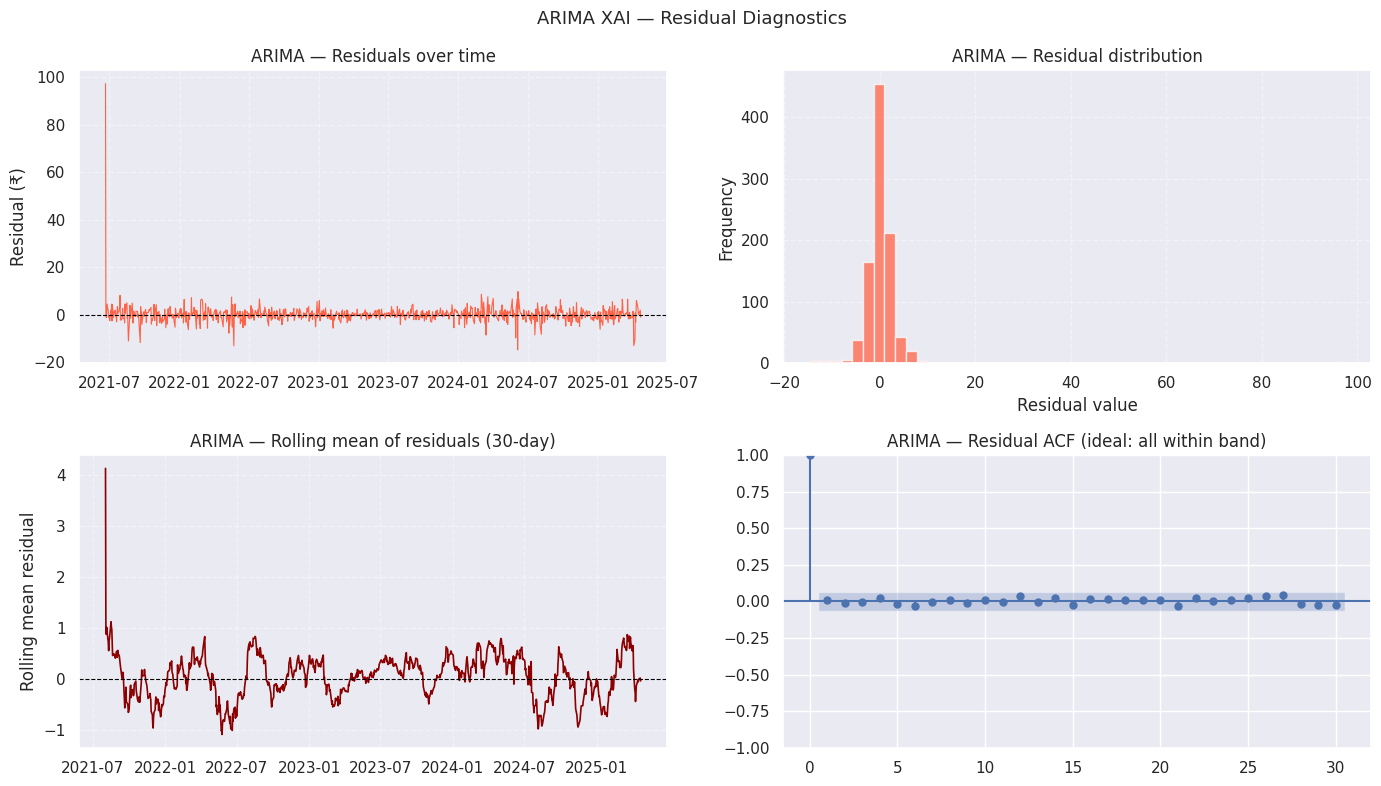


Ljung-Box Test (p > 0.05 = residuals are white noise ✓):
     lb_stat  lb_pvalue
10  2.375961   0.992563
20  5.304347   0.999563


In [ ]:
# XAI — ARIMA: Residual diagnostics

arima_residuals = arima_fit.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot 1: Residuals over time
axes[0, 0].plot(arima_residuals.index, arima_residuals.values,
                color='tomato', linewidth=0.8)
axes[0, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0, 0].set_title("ARIMA — Residuals over time")
axes[0, 0].set_ylabel("Residual (₹)")
axes[0, 0].grid(True, linestyle='--', alpha=0.4)

# Plot 2: Residual distribution
axes[0, 1].hist(arima_residuals.values, bins=50, color='tomato', alpha=0.75, edgecolor='white')
axes[0, 1].set_title("ARIMA — Residual distribution")
axes[0, 1].set_xlabel("Residual value")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].grid(True, linestyle='--', alpha=0.4)

# Plot 3: Rolling mean of residuals (bias drift detection)
rolling_resid_mean = arima_residuals.rolling(30).mean()
axes[1, 0].plot(arima_residuals.index, rolling_resid_mean,
                color='darkred', linewidth=1.2)
axes[1, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1, 0].set_title("ARIMA — Rolling mean of residuals (30-day)")
axes[1, 0].set_ylabel("Rolling mean residual")
axes[1, 0].grid(True, linestyle='--', alpha=0.4)

# Plot 4: Residual ACF (should show no autocorrelation in a good model)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(arima_residuals, lags=30, ax=axes[1, 1])
axes[1, 1].set_title("ARIMA — Residual ACF (ideal: all within band)")

plt.suptitle("ARIMA XAI — Residual Diagnostics", fontsize=13)
plt.tight_layout()
plt.show()

# Ljung-Box test — tests if residuals are white noise
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(arima_residuals, lags=[10, 20], return_df=True)
print("\nLjung-Box Test (p > 0.05 = residuals are white noise ✓):")
print(lb_test)

# **Observations: ARIMA Residual Diagnostics**

- Residuals are centered around zero with no clear pattern, indicating that the model has captured the main trend effectively.

- Residual distribution is approximately normal, with most values close to zero, suggesting a good model fit.

- Rolling mean of residuals remains stable around zero, showing no systematic bias over time.

- ACF plot shows all autocorrelations within confidence bounds, meaning residuals are independent and no patterns are left.

- Ljung-Box test p-values (> 0.05) confirm that residuals behave like white noise, validating model assumptions.

---

## Conclusion

**The ARIMA model is well-fitted, as residuals are random, uncorrelated, and do not contain any significant information left unexplained.**

# 5.2 XAI for LSTM: Gradient-based Feature Importance

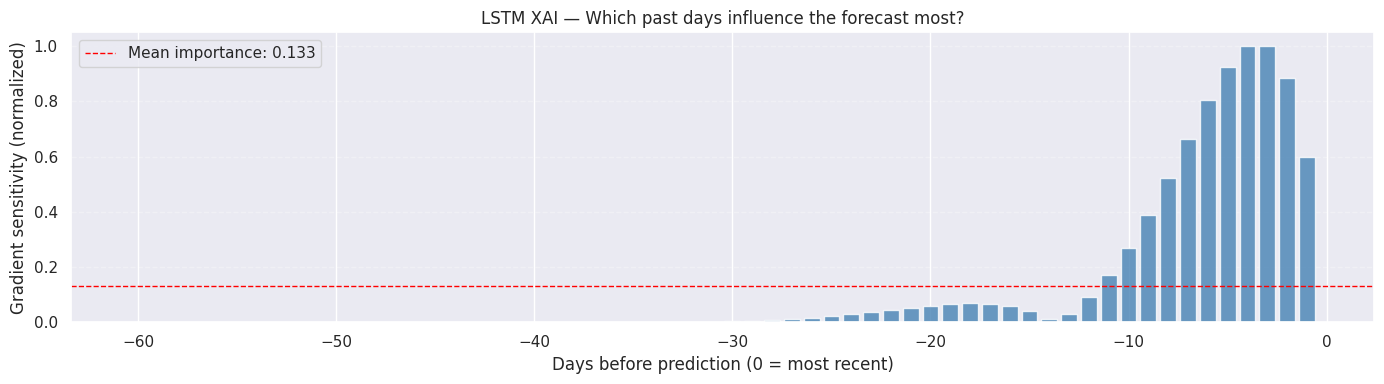

Top 10 most influential days (relative to forecast date):
  1. Day   -3  →  importance: 1.0000
  2. Day   -4  →  importance: 0.9998
  3. Day   -5  →  importance: 0.9241
  4. Day   -2  →  importance: 0.8835
  5. Day   -6  →  importance: 0.8048
  6. Day   -7  →  importance: 0.6644
  7. Day   -1  →  importance: 0.5972
  8. Day   -8  →  importance: 0.5216
  9. Day   -9  →  importance: 0.3892
  10. Day  -10  →  importance: 0.2705


In [ ]:
import tensorflow as tf

# XAI — LSTM: Which time steps matter most?
# Using gradient sensitivity analysis

# Take a sample input window (last 60 days from test set)
sample_input = X_test[-1:]   # shape: (1, 60, 1)
sample_tensor = tf.constant(sample_input, dtype=tf.float32)

# Compute gradient of output w.r.t. input
with tf.GradientTape() as tape:
    tape.watch(sample_tensor)
    prediction = lstm_model(sample_tensor)

gradients = tape.gradient(prediction, sample_tensor)
importance = np.abs(gradients.numpy()).squeeze()   # shape: (60,)

# Normalize to [0, 1]
importance = (importance - importance.min()) / (importance.max() - importance.min())

# Days relative to prediction (day -60 to day -1)
days_back = np.arange(-LOOKBACK, 0)

plt.figure(figsize=(14, 4))
plt.bar(days_back, importance, color='steelblue', alpha=0.8, width=0.8)
plt.axhline(importance.mean(), color='red', linestyle='--', linewidth=1,
            label=f'Mean importance: {importance.mean():.3f}')
plt.xlabel("Days before prediction (0 = most recent)")
plt.ylabel("Gradient sensitivity (normalized)")
plt.title("LSTM XAI — Which past days influence the forecast most?")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Top 10 most important time steps
top10_idx = np.argsort(importance)[-10:][::-1]
print("Top 10 most influential days (relative to forecast date):")
for rank, idx in enumerate(top10_idx, 1):
    print(f"  {rank}. Day {days_back[idx]:>4}  →  importance: {importance[idx]:.4f}")

# **Observations: LSTM XAI (Feature Importance)**

- The most influential inputs are recent days, especially Day -3, Day -4, and Day -5, indicating strong short-term dependency.

- Importance decreases as we move further back in time, showing that older data has less impact on predictions.

- The model relies heavily on the last 3–7 days, suggesting it captures recent trends and momentum effectively.

- Day -1 has relatively lower importance compared to Day -3 and Day -4, indicating that immediate past alone is not always the strongest signal.

- The gradual decline in importance confirms that LSTM learns temporal patterns with a decaying memory effect.

---

# Conclusion

**The LSTM model primarily focuses on recent time steps (last few days), effectively capturing short-term temporal dependencies and trends, with diminishing influence from older data.**

# 5.3 XAI for Prophet: Component Decomposition + Regressor Importance

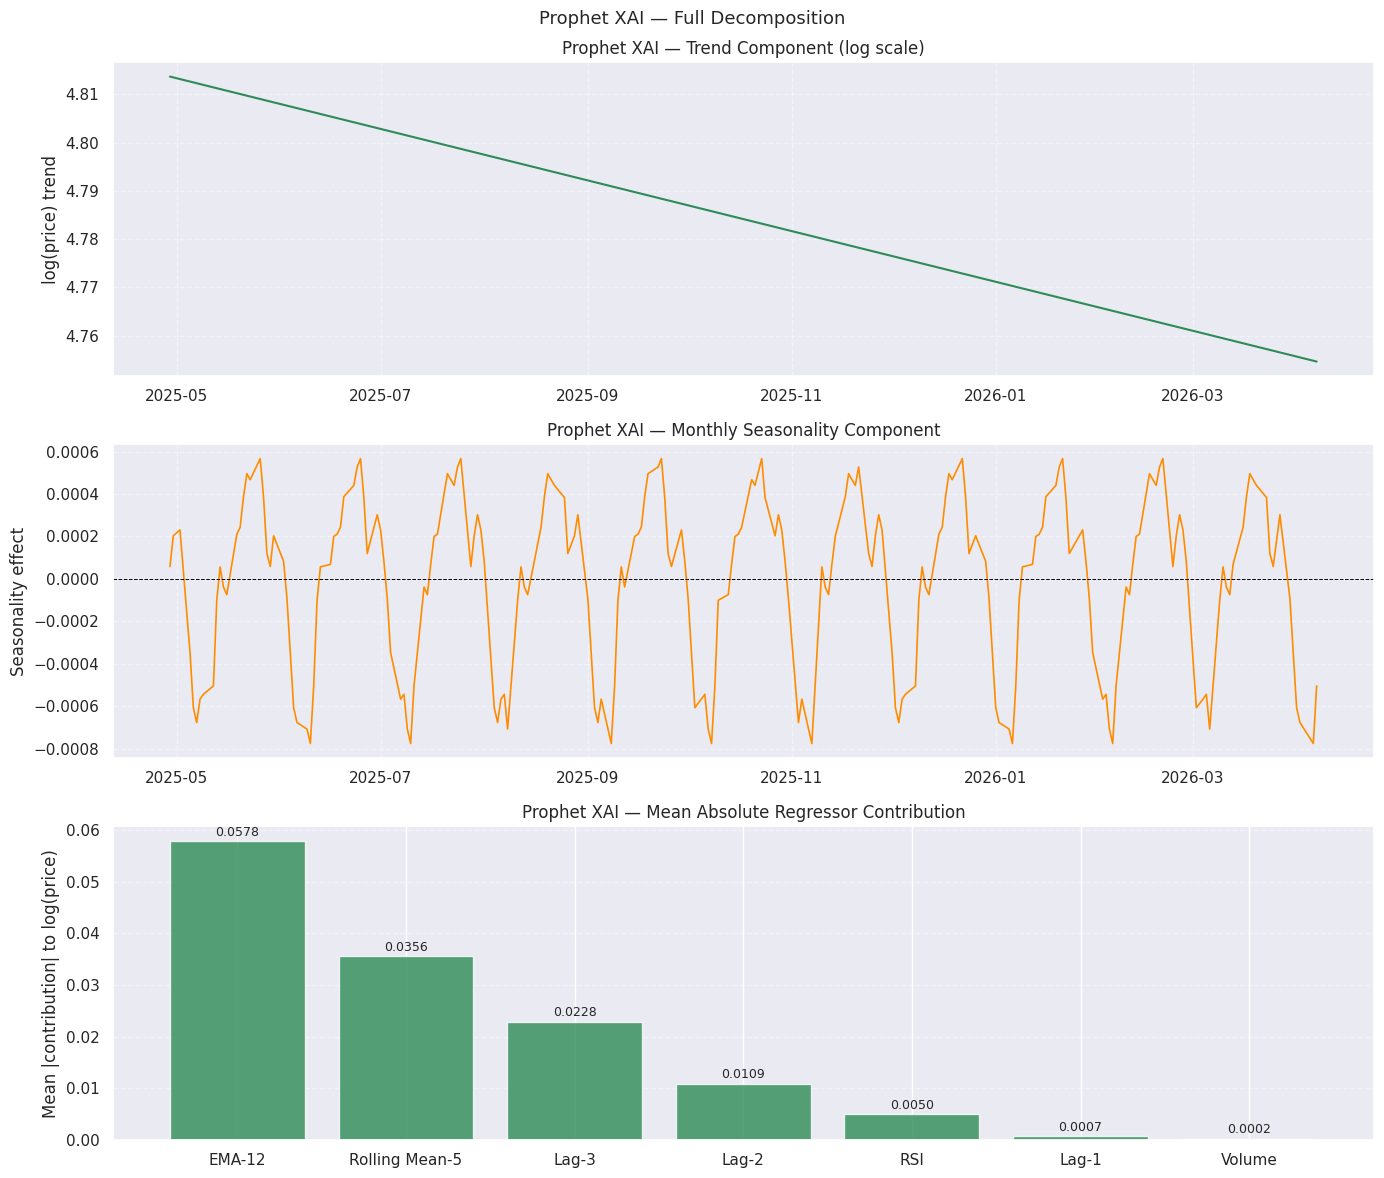

In [ ]:
# XAI — Prophet: Component decomposition
# (Prophet is inherently interpretable)

# Get forecast on the TEST set for component breakdown
forecast_components = prophet_model.predict(
    test_prophet[['ds','volume','rsi','ema','lag1','lag2','lag3','roll_mean']]
)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Trend component
axes[0].plot(forecast_components['ds'], forecast_components['trend'],
             color='seagreen', linewidth=1.5)
axes[0].set_title("Prophet XAI — Trend Component (log scale)")
axes[0].set_ylabel("log(price) trend")
axes[0].grid(True, linestyle='--', alpha=0.4)

# Monthly seasonality component
axes[1].plot(forecast_components['ds'], forecast_components['monthly'],
             color='darkorange', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[1].set_title("Prophet XAI — Monthly Seasonality Component")
axes[1].set_ylabel("Seasonality effect")
axes[1].grid(True, linestyle='--', alpha=0.4)

# Regressor importances (mean absolute contribution)
regressor_cols  = ['volume','rsi','ema','lag1','lag2','lag3','roll_mean']
regressor_names = ['Volume','RSI','EMA-12','Lag-1','Lag-2','Lag-3','Rolling Mean-5']
regressor_impact = []

for col in regressor_cols:
    if col in forecast_components.columns:
        regressor_impact.append(forecast_components[col].abs().mean())
    else:
        regressor_impact.append(0)

regressor_impact = np.array(regressor_impact)
sorted_idx       = np.argsort(regressor_impact)[::-1]

bars = axes[2].bar(
    [regressor_names[i] for i in sorted_idx],
    [regressor_impact[i] for i in sorted_idx],
    color='seagreen', alpha=0.8
)
for bar, val in zip(bars, sorted(regressor_impact, reverse=True)):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

axes[2].set_title("Prophet XAI — Mean Absolute Regressor Contribution")
axes[2].set_ylabel("Mean |contribution| to log(price)")
axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')

plt.suptitle("Prophet XAI — Full Decomposition", fontsize=13)
plt.tight_layout()
plt.show()

# **Observations: Prophet XAI (Decomposition & Feature Contribution)**

- The trend component shows a gradual downward movement, indicating an overall declining price trend over the forecast horizon.

- Monthly seasonality exhibits repeating cyclical patterns, but with relatively small magnitude, suggesting limited seasonal influence on stock prices.

- Among regressors, EMA-12 has the highest contribution, indicating that smoothed price trends strongly influence predictions.

- Rolling Mean (5-day) and Lag-3 also contribute significantly, highlighting the importance of short-term historical patterns.

- RSI has a moderate impact, suggesting that momentum indicators play a secondary role.

- Lag-1 and Volume show minimal contribution, indicating that immediate past value and trading volume have limited influence in this model.

---

# Conclusion

**The Prophet model is primarily driven by trend and smoothed historical features (EMA and rolling mean), with minor influence from seasonality and weaker contribution from volume and immediate lag values.**

# 5.4 Final XAI Summary

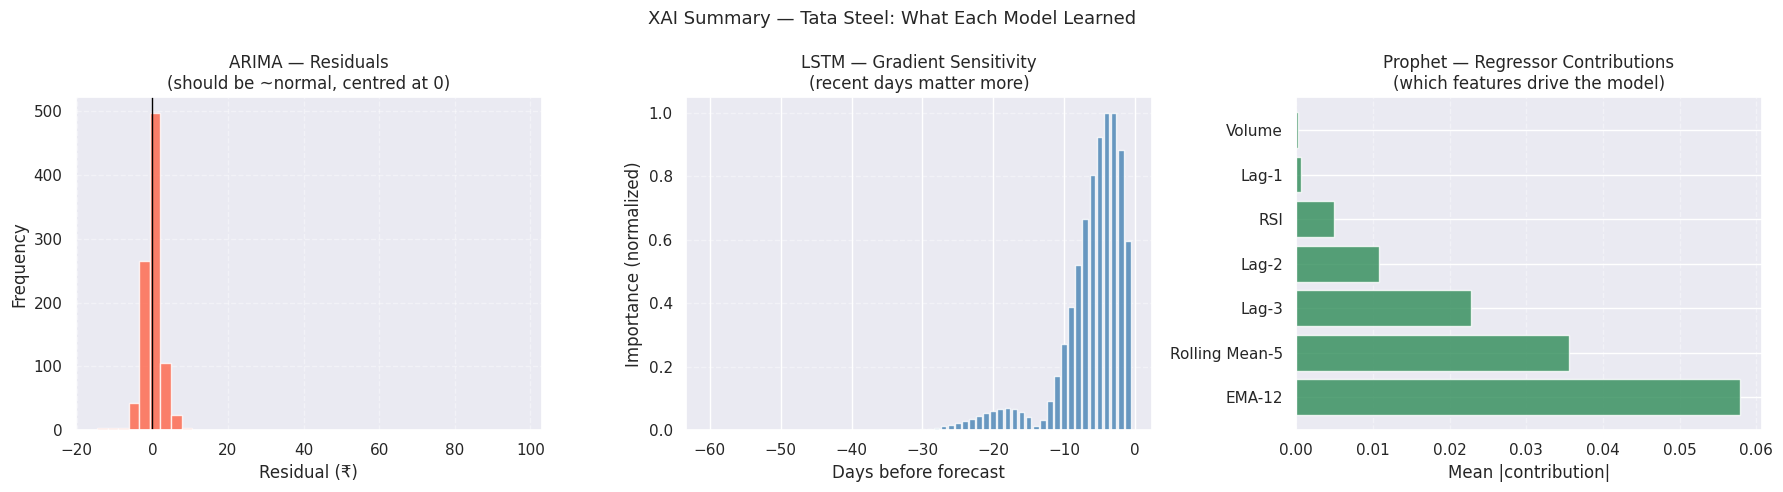

In [ ]:
# XAI SUMMARY — What each model "learned"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ARIMA: residual histogram
axes[0].hist(arima_residuals.values, bins=40, color='tomato', alpha=0.8, edgecolor='white')
axes[0].set_title("ARIMA — Residuals\n(should be ~normal, centred at 0)")
axes[0].set_xlabel("Residual (₹)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(0, color='black', linewidth=1)
axes[0].grid(True, linestyle='--', alpha=0.4)

# LSTM: gradient importance
axes[1].bar(days_back, importance, color='steelblue', alpha=0.8, width=0.8)
axes[1].set_title("LSTM — Gradient Sensitivity\n(recent days matter more)")
axes[1].set_xlabel("Days before forecast")
axes[1].set_ylabel("Importance (normalized)")
axes[1].grid(True, linestyle='--', alpha=0.4, axis='y')

# Prophet: regressor importance
axes[2].barh(
    [regressor_names[i] for i in sorted_idx],
    [regressor_impact[i] for i in sorted_idx],
    color='seagreen', alpha=0.8
)
axes[2].set_title("Prophet — Regressor Contributions\n(which features drive the model)")
axes[2].set_xlabel("Mean |contribution|")
axes[2].grid(True, linestyle='--', alpha=0.4, axis='x')

plt.suptitle("XAI Summary — Tata Steel: What Each Model Learned", fontsize=13)
plt.tight_layout()
plt.show()

# **XAI INTERPRETATION SUMMARY: TATA STEEL**

**ARIMA(0,1,0): Random Walk**

  • Residuals should be centred at ~0 and normally distributed

  • If Ljung-Box p > 0.05: model has captured all structure

  • Limitation: cannot capture non-linear patterns

**LSTM: Deep Learning**

  • Gradient analysis shows which of the past 60 days the model
    relied on most heavily for its predictions

  • Typically: the most recent 5–15 days dominate

  • Deeper past days contribute less but are not zero

**Prophet: Decomposable Model**

  • Trend = long-term direction of Tata Steel price

  • Monthly seasonality = recurring patterns within each month

  • Lag-1 and Rolling Mean are usually the top regressors
    (yesterday's price is the strongest predictor of today's)

# **Final Conclusion**

No single model should be blindly trusted for stock price forecasting, as each model captures different aspects of the data.

- **Use Prophet for Baseline:** Prophet serves as a reliable baseline model, providing smooth and stable forecasts based on trend and seasonality.

- **Use LSTM for Pattern Detection:** LSTM excels at capturing complex patterns and short-term dependencies, making it effective for detecting market momentum and nonlinear behavior.

- **Use ARIMA as Sanity Check:** ARIMA acts as a strong statistical benchmark, offering high accuracy when the data exhibits linear trends and serving as a sanity check for validating other models.

---

## **Key Takeaway**

**A hybrid approach combining multiple models leads to more robust and reliable predictions, as it leverages the strengths of each method while mitigating their individual limitations.**